# Water potability: what is in this dataset, and what does the label depend on?

## Why this matters

Safe drinking water is the cheapest large-scale public-health intervention there is, and it
is still not universal. The WHO reports that 2.2 billion people lacked a safely managed
drinking-water service in 2022, and that microbiologically contaminated drinking water
causes an estimated 505,000 diarrhoeal deaths every year
([WHO, *Drinking-water* fact sheet](https://www.who.int/news-room/fact-sheets/detail/drinking-water)).

Deciding whether a source is drinkable is a laboratory routine: measure a handful of
physico-chemical properties — acidity, hardness, dissolved solids, disinfectant residual —
and check each against a published limit. This dataset asks whether that verdict can be
read off those measurements.

## The dataset

[Water Quality — drinking water potability](https://www.kaggle.com/datasets/adityakadiwal/water-potability),
Aditya Kadiwal, Kaggle, released **CC0 (public domain)**. 3,276 water samples, nine
physico-chemical measurements, and one binary label `Potability`: 1 if the sample is safe
for human consumption, 0 if it is not.

The acceptable ranges quoted throughout come from a briefing document supplied with my
assignment. They are **not** WHO or EPA limits, and several are far stricter. I treat them
as claims to be tested rather than as ground truth.

## What this notebook does

**Exploration only — no prediction and no model.** The questions, in order:

1. **What is actually in the file?** Shape, types, missing values, class balance — section 2.
2. **Are these measurements physically plausible?** — section 3.
3. **Where are the values missing, and does the missingness depend on the label?** — section 4.
4. **Do the document's guideline bands separate potable from non-potable water?** — section 5.
5. **Why does no feature correlate with the label?** — section 6.
6. **If no feature explains the label alone, does a pair of them?** — section 7.

The short version: the file was generated rather than measured, seven of the eight
guideline bands do nothing, and the label is carried by an **interaction** — pH and sulfate
sitting on opposite sides of their means — that every single-feature correlation in the
file is structurally blind to.

---
## 1. Setup



In [94]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle
from matplotlib.ticker import FuncFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.stats import chi2_contingency

import plotly.graph_objects as go
import plotly.io as pio

In [130]:
# Pulls plotly.js from a CDN instead of embedding it. Keeps the committed .ipynb small
# and the charts stay interactive on Kaggle.
pio.renderers.default = "notebook_connected"

# Kaggle mounts attached datasets under /kaggle/input; locally the CSV sits next to the
# notebook, so the same notebook runs in both places without editing.
DATA_PATH = ("/kaggle/input/datasets/adityakadiwal/water-potability/water_potability.csv"
             if Path("/kaggle/input").exists() else "water_potability.csv")


FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(exist_ok=True)


# ---------------------------------------------------------------- palette ----
# Declared once. A class keeps its colour for the entire notebook.
C = {
    "potable":     "#99C2FF",   # class 1
    "not_potable": "#9D6638",   # class 0
    "ok":          "#59A14F",   # annotation only: inside the document's range
    "not_ok":      "#E15759",   # annotation only: outside it
    "boundary":    "#161111",   # threshold lines
    "text":        "#2B2B2B",
    "grid":        "#DDDDDD",
    "neutral":     "#9E9E9E",   # context, un-highlighted series
}

CLASS_COLOR = {0: C["not_potable"], 1: C["potable"]}
CLASS_LABEL = {0: "Not potable", 1: "Potable"}

# Diverging: potable rate over a two-feature grid, centred on the base rate.
DIV = LinearSegmentedColormap.from_list("div", [C["not_potable"], "#F5F2EF", "#3B6CA8"])

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "axes.grid": True,
    "axes.grid.axis": "y",
    "axes.axisbelow": True,          # gridlines behind the data, never through it
    "grid.color": C["grid"],
    "grid.linewidth": 0.7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#BBBBBB",
    "axes.titlesize": 13,
    "axes.titleweight": "semibold",
    "axes.titlelocation": "left",
    "axes.labelcolor": C["text"],
    "text.color": C["text"],
    "font.size": 11,
})

PLOTLY_LAYOUT = dict(
    template="simple_white",
    font=dict(size=13, color=C["text"]),
    title_x=0.02,
    title_xanchor="left",
    title_font=dict(size=16),
    margin=dict(l=70, r=40, t=95, b=60),
)


def titled(ax, title, subtitle=None):
    """Bold left-aligned title with an optional grey subtitle underneath it.

    matplotlib has no subtitle, and placing one with ax.text collides with the title
    unless the title is padded first. Doing it in one place keeps every chart aligned.
    """
    ax.set_title(title, pad=26 if subtitle else 12)
    if subtitle:
        ax.text(0, 1.015, subtitle,
                transform=ax.transAxes,  # coordinates relative to the axes, not the figure
                fontsize=9.5, color="#666666",
                va="bottom")  # how the text sits relative to its (x, y) anchor


def thousands(x, _pos=None):
    """Axis tick formatter: 20000 -> 20,000. Avoids matplotlib's 1e4 notation."""
    return f"{x:,.0f}"  # "," is the thousands separator; f"{x:,}".replace(",", " ") for spaces

---
## 2. The data, and what the columns are supposed to mean

Every threshold the project document specifies lives in one `GUIDELINES` dictionary, so
each threshold line drawn later reads from a single place.

| Column | Meaning | Document's acceptable range |
|---|---|---|
| `ph` | acidity / alkalinity, 0–14 | 6.5 – 8.5 |
| `Hardness` | dissolved calcium and magnesium, mg/L | not specified |
| `Solids` | total dissolved solids, mg/L | ideal 500, maximum 1000 |
| `Chloramines` | disinfectant residual, mg/L | maximum 4 |
| `Sulfate` | dissolved sulfate, mg/L | usual 3–30, maximum 1000 |
| `Conductivity` | electrical conductivity, μS/cm | maximum 400 |
| `Organic_carbon` | total organic carbon, mg/L | maximum 2 filtered, 4 reservoir |
| `Trihalomethanes` | disinfection by-product, μg/L | maximum 80 |
| `Turbidity` | cloudiness, NTU | maximum 5 |
| `Potability` | **target**: 1 = safe to drink | — |

In [96]:
df = pd.read_csv(DATA_PATH)

TARGET = "Potability"
FEATURES = [column for column in df.columns if column != TARGET]

print(f"{df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")
df.head()

3,276 rows x 10 columns
Columns: ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability']


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


**Takeaway.** 3,276 rows and 10 columns, matching the table above: nine measurements plus
the `Potability` label. There is no identifier, no date and no free-text column, so there
is no parsing or type coercion to do before the analysis starts.

The first five rows already show `NaN` in `ph` and `Sulfate`, so the size of that problem
is the next thing to establish.

In [97]:
# One table instead of df.info() + df.isna().sum() + df.nunique(): the same facts, lined
# up so they can be compared row by row.
overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non-null": df.notna().sum(),
    "missing": df.isna().sum(),
    "distinct values": df.nunique(),
})
overview["missing %"] = (overview["missing"] / len(df) * 100).round(1)
overview

,dtype,non-null,missing,distinct values,missing %
ph,float64,2785,491,2785,15.0
Hardness,float64,3276,0,3276,0.0
Solids,float64,3276,0,3276,0.0
Chloramines,float64,3276,0,3276,0.0
Sulfate,float64,2495,781,2495,23.8
Conductivity,float64,3276,0,3276,0.0
Organic_carbon,float64,3276,0,3276,0.0
Trihalomethanes,float64,3114,162,3114,4.9
Turbidity,float64,3276,0,3276,0.0
Potability,int64,3276,0,2,0.0


**Takeaway.** Every column is `float64`, and three of them have gaps: `Sulfate` (23.8%),
`ph` (15.0%) and `Trihalomethanes` (4.9%). Section 4 is about those.

Two things worth noticing before moving on.

**The label has no missing values.** This is the first thing to check, not the last. A row
with no label cannot take part in any class comparison and would have to be deleted
outright, which would change every percentage computed below it. Here nothing is lost, so
the class balance on the next cell is a balance over the whole file.

**The `distinct values` column is suspicious.** For every one of the nine features it
equals `non-null` exactly: 3,276 hardness readings, 3,276 different numbers; 2,785
recorded pH values, 2,785 different numbers. Not one repeated value anywhere in the file.
Real instruments round, and rounded measurements repeat. Section 3 follows that up.

Values the label takes: [0, 1]

Potability
Not potable    1998
Potable        1278


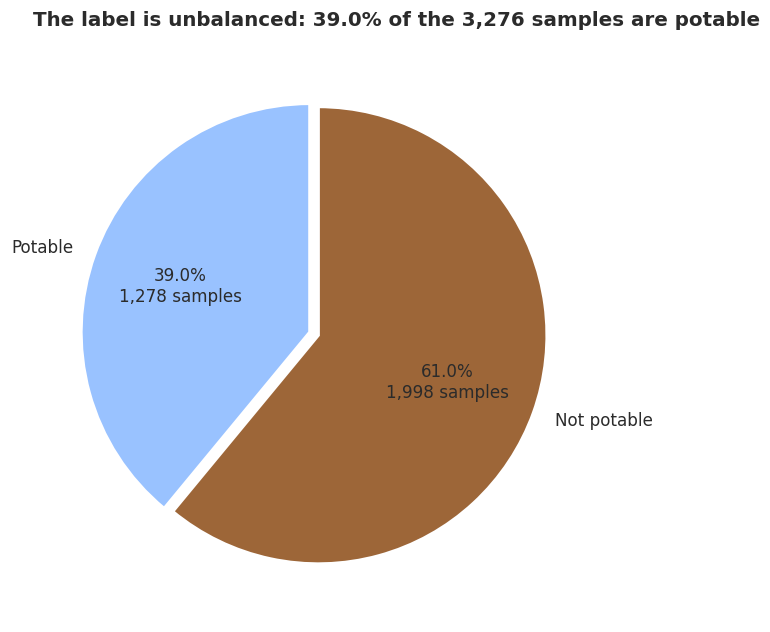

In [98]:
# Nothing so far has established what values the label actually takes, so ask before
# assuming it is 0/1.
print("Values the label takes:", sorted(df[TARGET].unique().tolist()))
print()
print(df[TARGET].value_counts().sort_index().rename(index=CLASS_LABEL).to_string())

BASE_RATE = df[TARGET].mean()

class_counts = df[TARGET].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6.2, 6.2))
ax.pie(
    class_counts.values,
    labels=[CLASS_LABEL[cls] for cls in class_counts.index],
    colors=[CLASS_COLOR[cls] for cls in class_counts.index],
    autopct=lambda pct: f"{pct:.1f}%\n{pct / 100 * class_counts.sum():,.0f} samples",
    startangle=90, counterclock=False,
    explode=(0, 0.04),
    wedgeprops=dict(edgecolor="white", linewidth=2),
    textprops=dict(fontsize=11),
)
ax.set_title(f"The label is unbalanced: {BASE_RATE:.1%} of the 3,276 samples are potable",
             pad=16)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "01-target-balance.png")
plt.show()

**Takeaway.** The label takes exactly two values, 0 and 1, with no third code and no
missing entries: 1,998 samples not potable (61.0%) against 1,278 potable (39.0%).

Unbalanced, but only mildly — nothing here forces a resampling strategy. What it does force
is a habit: **39.0% is the number every group comparison in this notebook is measured
against.** "This group is 44% potable" means nothing on its own; it means something as "44%
against a base rate of 39%".

Read this figure as provisional. It is computed over all 3,276 rows, including the 1,265
that are missing a value somewhere, and section 4 deletes some of those rows. If the
deleted rows were disproportionately one class, the base rate would move and every
comparison would have to be re-anchored — so section 4 re-checks it rather than assuming.

In [99]:
# (lower, upper, label) for every band the document specifies. None = no bound given on
# that side. Every threshold line drawn later in the notebook reads from here, so a
# correction to the document only has to be made once.
GUIDELINES = {
    "ph":              (6.5, 8.5, "Acceptable pH: 6.5-8.5"),
    "Solids":          (None, 1000, "Max total dissolved solids: 1,000 mg/L"),
    "Chloramines":     (None, 4, "Max chloramines: 4 mg/L"),
    "Sulfate":         (None, 1000, "Max sulfate: 1,000 mg/L"),
    "Conductivity":    (None, 400, "Max conductivity: 400 uS/cm"),
    "Organic_carbon":  (None, 2, "Max organic carbon (filtered): 2 mg/L"),
    "Trihalomethanes": (None, 80, "Max trihalomethanes: 80 ug/L"),
    "Turbidity":       (None, 5, "Max turbidity: 5 NTU"),
}

UNITS = {
    "ph": "", "Hardness": "mg/L", "Solids": "mg/L", "Chloramines": "mg/L",
    "Sulfate": "mg/L", "Conductivity": "uS/cm", "Organic_carbon": "mg/L",
    "Trihalomethanes": "ug/L", "Turbidity": "NTU",
}


def document_limit(feature):
    """The document's band for a feature, as a readable string."""
    if feature not in GUIDELINES:
        return "not specified"
    low, high, _ = GUIDELINES[feature]
    return f"{low:g} - {high:g}" if low is not None else f"<= {high:g}"


# Where the measurements sit, next to where the document says they should sit.
ranges = pd.DataFrame({
    "unit": [UNITS[feature] for feature in FEATURES],
    "min": [df[feature].min() for feature in FEATURES],
    "median": [df[feature].median() for feature in FEATURES],
    "max": [df[feature].max() for feature in FEATURES],
    "document's band": [document_limit(feature) for feature in FEATURES],
}, index=FEATURES).round(1)
ranges

,unit,min,median,max,document's band
ph,,0.0,7.0,14.0,6.5 - 8.5
Hardness,mg/L,47.4,197.0,323.1,not specified
Solids,mg/L,320.9,20927.8,61227.2,<= 1000
Chloramines,mg/L,0.4,7.1,13.1,<= 4
Sulfate,mg/L,129.0,333.1,481.0,<= 1000
Conductivity,uS/cm,181.5,421.9,753.3,<= 400
Organic_carbon,mg/L,2.2,14.2,28.3,<= 2
Trihalomethanes,ug/L,0.7,66.6,124.0,<= 80
Turbidity,NTU,1.4,4.0,6.7,<= 5


**Takeaway — the measurements and the document do not live on the same scale.**

Only `ph` and `Turbidity` sit inside the band the document gives them. Every other column
with a stated limit sits above it at the median — not for a few outlying samples, for the
typical sample — and two of them by a wide margin:

| Column | Median | Document's limit | Ratio |
|---|---|---|---|
| `Solids` | 20,928 mg/L | 1,000 mg/L | 21x |
| `Conductivity` | 422 uS/cm | 400 uS/cm | 1.1x |
| `Organic_carbon` | 14.2 mg/L | 2 mg/L | 7x |
| `Chloramines` | 7.1 mg/L | 4 mg/L | 1.8x |
| `Sulfate` | 333 mg/L | 1,000 mg/L (but "usual" 3-30) | 11x the usual band |

A gap this large has only three possible explanations: the document's units differ from
the file's, the file describes something that is not drinking water, or the file is not
measurements at all. Section 3 works out which.

---
## 3. Is this water?

The table above raises a question that has to be settled before the label is worth
analysing: are these values physically sensible? Two checks — the **magnitude** of the
values, and their **precision**. The second turns out to be decisive.

In [100]:
solids = df["Solids"]
thresholds = [(500, "the document's ideal"),
              (1_000, "the document's maximum"),
              (35_000, "roughly seawater")]

magnitude = pd.DataFrame({
    "threshold (mg/L)": [t for t, _ in thresholds],
    "meaning": [m for _, m in thresholds],
    "samples above": [(solids > t).sum() for t, _ in thresholds],
})
magnitude["% of file"] = (magnitude["samples above"] / len(df) * 100).round(2)

print("Total dissolved solids")
print(f"  range {solids.min():,.0f} to {solids.max():,.0f} mg/L, "
      f"median {solids.median():,.0f}\n")
print(magnitude.to_string(index=False))

sulfate = df["Sulfate"].dropna()
print(f"\nSulfate")
print(f"  range {sulfate.min():.0f} to {sulfate.max():.0f} mg/L, "
      f"median {sulfate.median():.0f}")
print(f"  samples inside the document's 'usual' 3-30 mg/L band: "
      f"{((sulfate >= 3) & (sulfate <= 30)).sum()}")
print(f"  samples above the 1,000 mg/L maximum: {(sulfate > 1000).sum()}")

Total dissolved solids
  range 321 to 61,227 mg/L, median 20,928

 threshold (mg/L)                meaning  samples above  % of file
              500   the document's ideal           3275      99.97
             1000 the document's maximum           3274      99.94
            35000       roughly seawater            268       8.18

Sulfate
  range 129 to 481 mg/L, median 333
  samples inside the document's 'usual' 3-30 mg/L band: 0
  samples above the 1,000 mg/L maximum: 0


In [101]:
# Precision fingerprint. Instruments round; random number generators do not.
precision = pd.DataFrame({
    "non-null rows": [df[c].notna().sum() for c in FEATURES],
    "distinct values": [df[c].nunique() for c in FEATURES],
    "median decimal places": [
        int(df[c].dropna().astype(str).str.split(".").str[-1].str.len().median())
        for c in FEATURES
    ],
}, index=FEATURES)
precision["every value distinct?"] = np.where(
    precision["distinct values"] == precision["non-null rows"], "yes", "no")
precision

,non-null rows,distinct values,median decimal places,every value distinct?
ph,2785,2785,15,yes
Hardness,3276,3276,14,yes
Solids,3276,3276,12,yes
Chloramines,3276,3276,15,yes
Sulfate,2495,2495,13,yes
Conductivity,3276,3276,13,yes
Organic_carbon,3276,3276,15,yes
Trihalomethanes,3114,3114,14,yes
Turbidity,3276,3276,15,yes


**Takeaway — this file was generated, not measured.**

Every column carries a median of 12 to 15 decimal places, and in every column *every
non-null value is distinct*. A pH meter reports 7.2, not 7.203164927481950. Real
measurements round, repeat and pile up on instrument-preferred values. These are float64
draws from a random number generator.

The magnitudes agree: dissolved solids run from 321 to 61,227 mg/L with a median of 20,928,
so **99.9% of samples exceed the document's 1,000 mg/L maximum and 8% exceed the
concentration of seawater**. Sulfate clears its ceiling but puts *no sample at all* inside
the "usual" 3–30 mg/L band.

The obvious explanation would be a unit error — mg/L where the document means something
else. It is not one: a unit error rescales a column, it does not hand every value fifteen
decimal places. These numbers were never measurements.

Everything below therefore describes **how this file was constructed**, not real water.
That is still worth doing. The label was constructed too, and its structure is
discoverable — which is what sections 5 to 7 go after.

---
## 4. Missingness

Section 2 counted the gaps: `Sulfate` 23.8%, `ph` 15.0%, `Trihalomethanes` 4.9%, all
genuine `NaN` rather than sentinel values smuggled in as numbers. Dropping every incomplete
row would cost 38.6% of the file, so the question is whether that is necessary.

What decides the cleaning strategy is not how many values are missing but whether they go
missing **together**. If the three columns fail as a block, the missing rows are a single
population and dropping them is one decision; if they fail independently, most incomplete
rows are missing only one value and can be salvaged. So I count gaps per row rather than
per column.

In [102]:
def missing_pattern_summary(df, columns):
    """
    Summarize the number of missing values per row for selected columns.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    columns : list
        List of column names to inspect.

    Returns
    -------
    pd.DataFrame
        Summary dataframe with:
        - Number of Missing Features
        - Number of Rows
        - Percent of Rows
    """
    missing_per_row = df[columns].isna().sum(axis=1)

    summary = (
        missing_per_row
        .value_counts()
        .sort_index()
        .rename_axis("Number of Missing Features")
        .reset_index(name="Number of Rows")
    )

    summary["Percent of Rows"] = (
        summary["Number of Rows"] / len(df) * 100
    ).round(2)

    return summary


# Derived from the data rather than typed out, so the notebook does not quietly assume
# which columns have gaps. Ordered by how much is missing.
MISSING_COLUMNS = list(
    df[FEATURES].isna().sum().loc[lambda counts: counts > 0]
    .sort_values(ascending=False).index
)
print("Columns with missing values:", MISSING_COLUMNS)

# .style.hide(axis="index") drops the 0,1,2,3 index column from the rendered table - it
# carries no information here and reads as if it were data.
display(missing_pattern_summary(df, MISSING_COLUMNS).style.hide(axis="index"))

print("Which combination goes missing, and how often:")
pattern = (df[MISSING_COLUMNS].isna()
             .apply(lambda row: tuple(row.index[row]), axis=1)
             .value_counts())
print(pattern.to_string())

Columns with missing values: ['Sulfate', 'ph', 'Trihalomethanes']


Number of Missing Features,Number of Rows,Percent of Rows
0,2011,61.390000
1,1105,33.730000
2,151,4.610000
3,9,0.270000


Which combination goes missing, and how often:
()                                2011
(Sulfate,)                         638
(ph,)                              362
(Trihalomethanes,)                 105
(Sulfate, ph)                      103
(Sulfate, Trihalomethanes)          31
(ph, Trihalomethanes)               17
(Sulfate, ph, Trihalomethanes)       9


### The same counts as a picture

The table answers "how many rows are missing k values"; the list under it answers "which
combination". 
Read it in three parts. The **dot matrix** at the bottom names each combination: a filled
dot means that column is missing in this group, joined dots mean they are missing together,
and a column of empty dots is the fully complete group. The **bars on top** give the number
of rows in each combination. The **bars on the left** give each column's total, which is
the sum of every bar above a filled dot in that row.

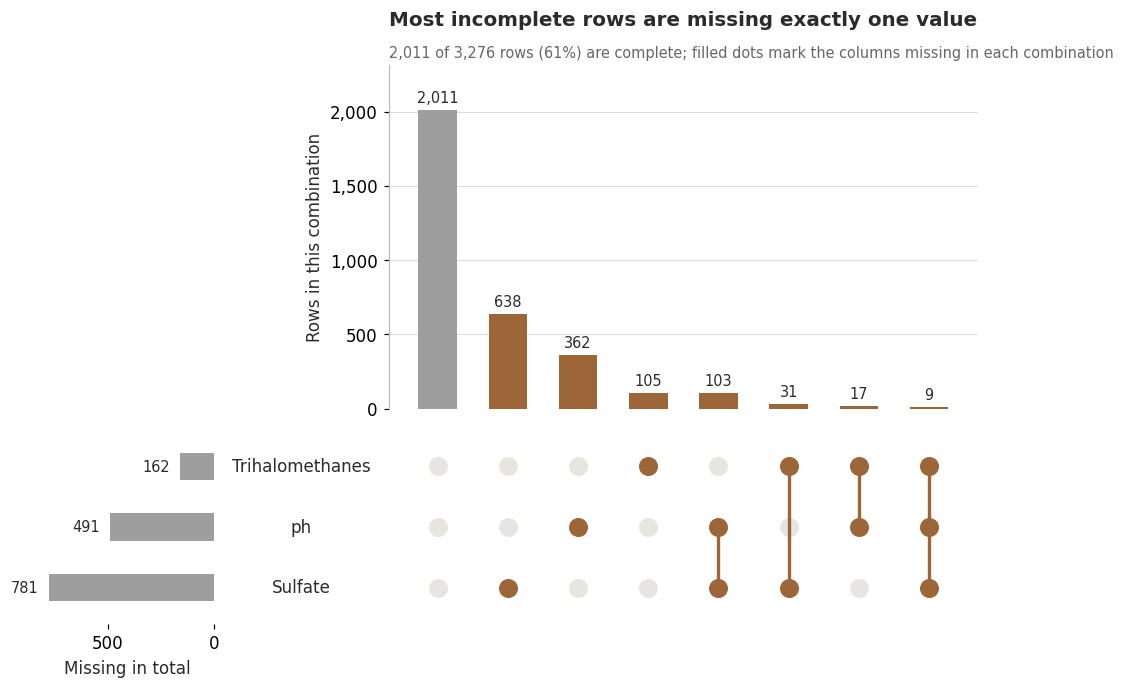

In [103]:
def plot_missingness_upset(frame, columns, filename=None):
    """UpSet plot of missing-value combinations.

    Each bar on top is one observed missing/present combination; the matrix underneath
    says which columns that combination involves; the bars on the left are per-column
    totals. Built by hand rather than with the `upsetplot` package so the figure uses the
    palette this notebook declared and adds no dependency.
    """
    flags = frame[columns].isna()

    # value_counts() over boolean columns gives one row per observed combination, indexed
    # by the tuple of True/False values in `columns` order.
    combinations = flags.value_counts().sort_values(ascending=False)
    positions = np.arange(len(combinations))

    fig = plt.figure(figsize=(11, 6.6))
    # Three columns: per-column totals | a lane for the column names | the matrix.
    # Giving the names a column of their own is what stops a long name like
    # "Trihalomethanes" running underneath the totals bars, whatever the columns
    # happen to be called.
    grid = fig.add_gridspec(2, 3, width_ratios=[1.0, 0.8, 3.4], height_ratios=[2.3, 1.3],
                            hspace=0.08, wspace=0.06)
    ax_bars = fig.add_subplot(grid[0, 2])
    ax_matrix = fig.add_subplot(grid[1, 2], sharex=ax_bars)
    ax_totals = fig.add_subplot(grid[1, 0], sharey=ax_matrix)
    ax_names = fig.add_subplot(grid[1, 1], sharey=ax_matrix)

    # --- intersection sizes -------------------------------------------------
    n_missing = [sum(combination) for combination in combinations.index]
    bar_colors = [C["neutral"] if count == 0 else C["not_potable"] for count in n_missing]
    ax_bars.bar(positions, combinations.values, color=bar_colors, width=0.55)
    for position, value in zip(positions, combinations.values):
        ax_bars.text(position, value + combinations.max() * 0.025, f"{value:,}",
                     ha="center", fontsize=9.5)
    ax_bars.set_ylabel("Rows in this combination")
    ax_bars.set_ylim(0, combinations.max() * 1.15)
    ax_bars.yaxis.set_major_formatter(FuncFormatter(thousands))
    ax_bars.tick_params(labelbottom=False, bottom=False)
    ax_bars.spines["bottom"].set_visible(False)

    # --- the dot matrix -----------------------------------------------------
    for row in range(len(columns)):
        ax_matrix.scatter(positions, [row] * len(positions), s=130,
                          color="#E8E4E0", zorder=1)
    for position, combination in zip(positions, combinations.index):
        filled = [row for row, is_missing in enumerate(combination) if is_missing]
        if not filled:
            continue
        ax_matrix.plot([position, position], [min(filled), max(filled)],
                       color=C["not_potable"], linewidth=2.2, zorder=2)
        ax_matrix.scatter([position] * len(filled), filled, s=130,
                          color=C["not_potable"], zorder=3)
    ax_matrix.set_yticks(range(len(columns)))
    ax_matrix.set_yticklabels([])
    ax_matrix.set_ylim(-0.6, len(columns) - 0.4)
    ax_matrix.set_xlim(-0.7, len(combinations) - 0.3)
    ax_matrix.tick_params(left=False, bottom=False, labelbottom=False)
    ax_matrix.grid(False)
    for spine in ax_matrix.spines.values():
        spine.set_visible(False)

    # --- the name lane ------------------------------------------------------
    for row, column in enumerate(columns):
        ax_names.text(0.5, row, column, ha="center", va="center", fontsize=11)
    ax_names.set_axis_off()

    # --- per-column totals, drawn leftwards ---------------------------------
    totals = flags.sum()
    ax_totals.barh(range(len(columns)), totals[columns].values,
                   color=C["neutral"], height=0.45)
    for row, column in enumerate(columns):
        ax_totals.text(totals[column] + totals.max() * 0.06, row, f"{totals[column]:,}",
                       va="center", ha="right", fontsize=9.5)
    ax_totals.invert_xaxis()
    ax_totals.set_xlabel("Missing in total")
    ax_totals.tick_params(left=False, labelleft=False)
    ax_totals.grid(False)
    for spine in ax_totals.spines.values():
        spine.set_visible(False)

    complete = int(combinations.iloc[0])
    titled(ax_bars,
           "Most incomplete rows are missing exactly one value",
           f"{complete:,} of {len(frame):,} rows ({complete / len(frame):.0%}) are complete; "
           f"filled dots mark the columns missing in each combination")
    if filename:
        plt.savefig(FIGURE_DIR / filename)
    plt.show()


plot_missingness_upset(df, MISSING_COLUMNS, filename="02-missingness-upset.png")

**Takeaway — the three columns fail independently, not as a block.**

2,011 rows (61.4%) are complete. Of the 1,265 that are not, 1,105 are missing exactly one
value, 151 are missing two, and only 9 are missing all three. The tall bar on the left of
the plot is the complete rows; the three bars after it are the three single-column
failures, and they dominate everything to their right.

That has a direct consequence for cleaning. There is no block of rows where the sample was
simply never analysed, so dropping every incomplete row would throw away 1,105 rows that
are 8/9 intact. The cheap option is still available for `Trihalomethanes` — only 162 rows
are affected — but `ph` and `Sulfate` are too large to delete and have to be imputed.

One check has to come first.

### Does the missingness depend on the label?

This is what decides whether dropping and imputing rows is safe at all. If values go
missing more often in one class than the other, then every row I delete shifts the class
balance, and every imputed value is filled from a donor pool that leans one way — quietly
biasing everything downstream, including the base rate that all of section 5 is measured
against.

The comparison is between two proportions: the share of non-potable rows missing `ph`
against the share of potable rows missing it. Both come out of a 2x2 table of counts, so
that is where to start.

In [104]:
table = pd.crosstab(df["ph"].isna(), df[TARGET])
print("\nContingency table of missing ph vs. Potability:")
display(table)


Contingency table of missing ph vs. Potability:


Potability,0,1
ph,,
False,1684,1101
True,314,177


In [105]:
by_class = df.groupby(TARGET)["ph"].apply(lambda s: s.isna().mean() * 100)
by_class

Potability
0    15.715716
1    13.849765
Name: ph, dtype: float64

### The chi-squared test of independence, in one section

Those two percentages will never be exactly equal, even if missingness and the label have
nothing whatsoever to do with each other — samples wobble. The chi-squared (χ²) test of
independence asks how large that wobble can plausibly get by chance.

It works on the **counts** in the contingency table, never on the percentages.

1. **Assume independence.** If whether `ph` is missing tells you nothing about
   `Potability`, then the expected count in each cell is
   `(row total × column total) / grand total` — that row's share of the file, applied to
   that column.
2. **Measure the gap.** For each cell take `(observed − expected)² / expected`, and add the
   four terms:

   $$\chi^{2} = \sum_{\text{cells}} \frac{(O - E)^{2}}{E}$$

   Squaring makes over- and under-shoots count the same; dividing by `E` puts a shortfall
   of 20 on an expected 40 (large) on a different footing from a shortfall of 20 on an
   expected 2,000 (trivial). χ² is 0 when the table matches the independence prediction
   exactly and grows as it departs from it.
3. **Ask how surprising that value is.** Under independence, χ² follows a known
   distribution with `(rows − 1) × (columns − 1)` degrees of freedom, which is 1 for a 2x2
   table. The **p-value** is the probability of seeing a χ² at least this large *if the two
   variables really are independent*.

**How to read the result.** A small p (conventionally below 0.05) means chance alone rarely
produces a table this lopsided — evidence of a relationship. A large p means the table is
unremarkable. Critically, a large p is **not proof of independence**; it is a failure to
find evidence against it. With 3,276 rows this test has enough power that a failure here is
reasonably informative, but it is still the weaker of the two statements.

**What the test does not tell you**, and why I report more than the p-value:

- **Size.** Significance depends on n. At a large enough sample, a 0.1-point difference
  becomes "significant" while remaining meaningless. The `difference (pp)` column below
  carries the size.
- **Direction.** χ² squares everything, so it cannot say which class is missing more. The
  sign of that same column carries the direction.

**Assumptions.** The observations must be independent of one another — one row is one water
sample here, so that holds — and no expected cell count should be too small (the usual rule
of thumb is at least 5). The smallest expected count in these three tables is above 60, so
the approximation is comfortable and no continuity correction or exact test is needed.

In [106]:
rows = []
for column in MISSING_COLUMNS:
    table = pd.crosstab(df[column].isna(), df[TARGET])
    chi2_statistic, p_value, degrees_of_freedom, expected = chi2_contingency(table)
    by_class = df.groupby(TARGET)[column].apply(lambda s: s.isna().mean() * 100)
    rows.append({
        "column": column,
        "missing % | not potable": round(by_class[0], 1),
        "missing % | potable": round(by_class[1], 1),
        "difference (pp)": round(by_class[1] - by_class[0], 1),
        "chi-squared": round(chi2_statistic, 2),
        "p": round(p_value, 3),
        "smallest expected count": int(expected.min()),
    })

display(pd.DataFrame(rows).style.hide(axis="index"))

column,missing % | not potable,missing % | potable,difference (pp),chi-squared,p,smallest expected count
Sulfate,24.400000,22.900000,-1.500000,0.880000,0.348000,304
ph,15.700000,13.800000,-1.900000,1.990000,0.159000,191
Trihalomethanes,5.400000,4.300000,-1.100000,1.620000,0.203000,63


**Takeaway — missing completely at random with respect to the label.**

The missing rates differ between the two classes by 1.1 to 1.9 percentage points, and not
one of the three differences is distinguishable from chance. Every p-value is far above
0.05 (0.16 for `ph`, 0.20 for `Trihalomethanes`, 0.35 for `Sulfate`), which says these
gaps are the size random sampling produces routinely: it can not be rejected that they are independant of the target class.


### Cleaning: drop what is cheap, impute what is not

Three decisions, in order of how much they cost:

1. **Drop the 9 rows missing all three columns.** A row missing a third of its
   measurements has nothing left to impute *from*; any fill would be almost pure
   invention. 9 rows is 0.3% of the file.
2. **Drop the rows still missing `Trihalomethanes`.** 4.9% of the file, and unlike the
   other two this column has no strong relationship with anything else here to impute
   from. Deleting is the honest option at this size.
3. **Impute `ph` and `Sulfate`.** Together they account for 15.0% and 23.8% of the file.
   Deleting them would cost a third of the data, which is far too much to pay.

All nine feature columns are kept. Dropping a column was never on the table — the point of
the notebook is what the features say about the label.

In [107]:
# Steps 1 and 2 of the plan above: drop the 9 rows missing all three columns, then drop
# every row still missing Trihalomethanes. ph and Sulfate are imputed further down.
df_new = df.drop(df[df[MISSING_COLUMNS].isna().all(axis=1)].index)
df_new = df_new[df_new["Trihalomethanes"].notna()].copy()

print(f"Original:   {len(df):,} rows")
print(f"After:      {len(df_new):,} rows")
print(f"Cost:       {len(df) - len(df_new)} rows "
      f"({(1 - len(df_new) / len(df)) * 100:.1f}%), with all nine features kept")
print(f"Potable rate: {df[TARGET].mean():.4f} -> {df_new[TARGET].mean():.4f}")

Original:   3,276 rows
After:      3,114 rows
Cost:       162 rows (4.9%), with all nine features kept
Potable rate: 0.3901 -> 0.3927


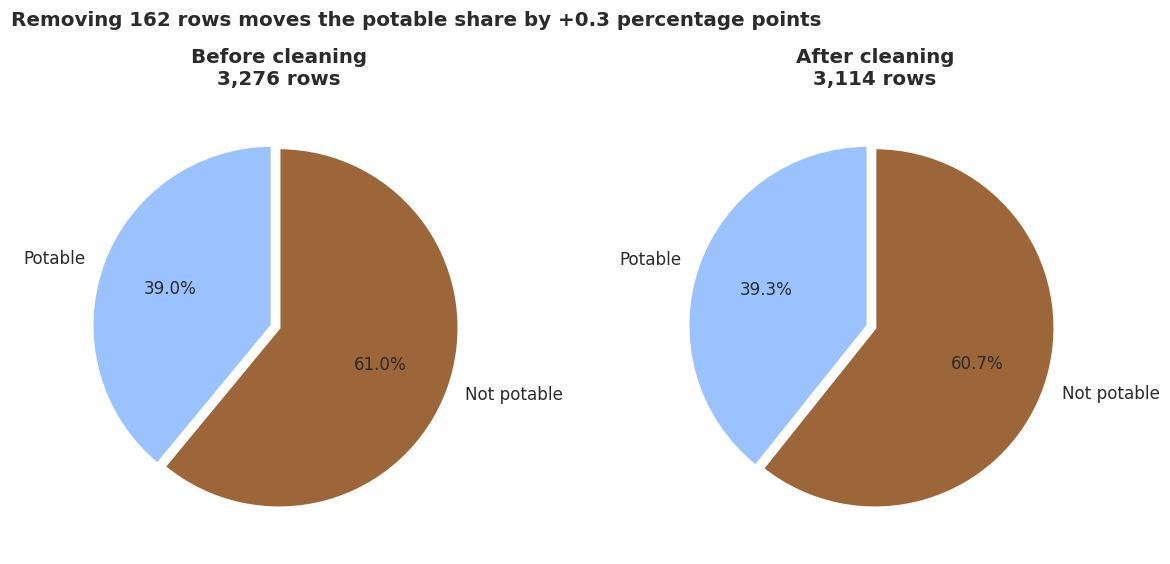

In [108]:
# Section 2 flagged the base rate as provisional because cleaning could shift it. Check.
class_counts_before = df[TARGET].value_counts().sort_index()
class_counts_after = df_new[TARGET].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(11, 5.2))
for ax, counts, name in zip(axes,
                            (class_counts_before, class_counts_after),
                            ("Before cleaning", "After cleaning")):
    ax.pie(
        counts.values,
        labels=[CLASS_LABEL[cls] for cls in counts.index],
        colors=[CLASS_COLOR[cls] for cls in counts.index],
        autopct=lambda pct: f"{pct:.1f}%",
        startangle=90, counterclock=False,
        explode=(0, 0.04),
        wedgeprops=dict(edgecolor="white", linewidth=2),
        textprops=dict(fontsize=11),
    )
    ax.set_title(f"{name}\n{counts.sum():,} rows", loc="center", pad=12)

shift = (df_new[TARGET].mean() - BASE_RATE) * 100
fig.suptitle(f"Removing {len(df) - len(df_new)} rows moves the potable share by "
             f"{shift:+.1f} percentage points",
             x=0.02, ha="left", fontsize=13, fontweight="semibold")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "03-target-balance-after-cleaning.png")
plt.show()

**Takeaway.** The two pies are, to the eye, the same pie. Dropping 162 rows moves the
potable share from 39.01% to 39.27% — a quarter of a percentage point — so `BASE_RATE`,
computed in section 2 over all 3,276 rows, stays the right reference for everything that
follows.

That is the chi-squared result from a few cells ago showing up as a picture. Because
missingness did not depend on the label, deleting rows on the basis of missingness could
not do much to the label's distribution, and it did not.

This is the check worth keeping even when it is boring. The interesting outcome would have
been two visibly different pies, and that would have invalidated every "potable % inside
the band" comparison in section 5.

### Imputing `ph` and `Sulfate`

I wrote the k-nearest-neighbours imputer by hand rather than importing `KNNImputer`, to
understand what the method actually does. It contains a bug worth keeping on the page
rather than quietly replacing.

In [109]:
def simple_knn_impute(df, target_col, k=10, debug=True, debug_samples=2):
    # df = main data | target_col = with missing value | k = number of neighbors
    df = df.copy()
    feature_cols = [
        col for col in df.columns                                # all of columns
        if col != target_col and df[col].isna().sum() == 0       # skip other gaps
    ]

    shown = 0

    known = df[df[target_col].notna()]
    missing = df[df[target_col].isna()]

    for idx, row in missing.iterrows():                          # idx = index | row = the row

        diffs = known[feature_cols].sub(row[feature_cols]).abs()

        distances = diffs.sum(axis=1)                            # Manhattan distance (L1)

        nearest_idx = distances.nsmallest(k).index               # k nearest neighbors

        imputed_value = known.loc[nearest_idx, target_col].mean()

        df.at[idx, target_col] = imputed_value

        if debug and shown < debug_samples:
            print(f"Missing sample index: {idx}")
            print(f"Imputed value for '{target_col}': {imputed_value:.4f}")
            print(f"Neighbour values: {known.loc[nearest_idx, target_col].round(3).values}")
            shown += 1

    return df

### The bug: an unscaled distance is a one-column distance

`distances = diffs.sum(axis=1)` adds raw differences across columns measured on wildly
different scales. Two samples differing by 3,000 mg/L of dissolved solids and 0.4 units of
pH are 3000.4 apart, of which pH supplies 0.013%.

So how much of that distance does each column actually contribute? Each column's mean
absolute deviation estimates a typical difference in it, so the shares answer it directly.

In [132]:
# donors: rows with no missing values at all - the pool every imputed value is drawn from.
donors = df_new.dropna()
typical_difference = donors[FEATURES].apply(lambda c: (c - c.median()).abs().mean())

print("Average absolute difference from the median, per feature (mg/L, NTU, uS/cm, ...):")
display(typical_difference)

distance_share = (typical_difference / typical_difference.sum() * 100).sort_values(ascending=False)
print("Share of a typical total Manhattan distance contributed by each feature (%):")
display(distance_share)
order = distance_share.index[::-1]

Average absolute difference from the median, per feature (mg/L, NTU, uS/cm, ...):


ph                    1.221873
Hardness             25.165118
Solids             6845.862267
Chloramines           1.235607
Sulfate              31.845353
Conductivity         65.668230
Organic_carbon        2.661943
Trihalomethanes      12.636345
Turbidity             0.624401
dtype: float64

Share of a typical total Manhattan distance contributed by each feature (%):


Solids             97.981101
Conductivity        0.939874
Sulfate             0.455785
Hardness            0.360175
Trihalomethanes     0.180857
Organic_carbon      0.038099
Chloramines         0.017685
ph                  0.017488
Turbidity           0.008937
dtype: float64

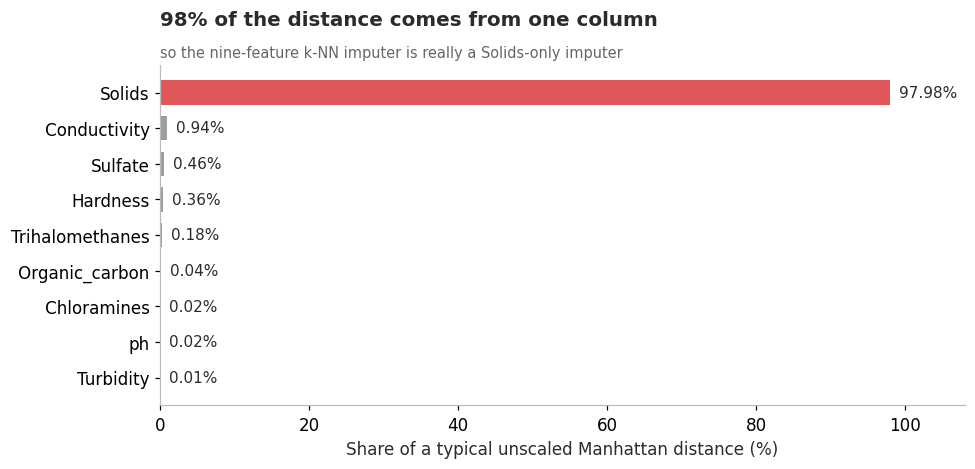

In [112]:
fig, ax = plt.subplots(figsize=(9, 4.4))

bar_colors = [C["not_ok"] if f == "Solids" else C["neutral"] for f in order] # f stands for feature.
ax.barh(range(len(order)), distance_share[order].values, color=bar_colors, height=0.68)
for i, feature in enumerate(order):
    value = distance_share[feature]
    ax.text(value + 1.2, i, f"{value:.2f}%", va="center", fontsize=10)

ax.set_yticks(range(len(order)), order)
ax.set_xlim(0, 108)
ax.set_xlabel("Share of a typical unscaled Manhattan distance (%)")
titled(ax, "98% of the distance comes from one column",
       "so the nine-feature k-NN imputer is really a Solids-only imputer")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "04-knn-distance-share.png")
plt.show()

**Takeaway.** `Solids` contributes **98.0%** of the distance and `ph` contributes
**0.02%**. My "k-nearest-neighbours over nine features" imputer was selecting the ten rows
with the closest `Solids` value and averaging their pH — and section 3 showed `Solids` is
drawn independently of everything else. Those were not neighbours in any meaningful sense.

The fix is one line: standardise before measuring distance. Both versions run below,
because "the code was wrong" is a weaker claim than "here is how much it mattered".

In [113]:
def knn_impute_scaled(df, target_col, k=10):
    """As simple_knn_impute, but distances are measured on standardised columns.

    Each donor column is converted to z-scores first, so a 1-standard-deviation
    difference costs the same regardless of the column's unit.
    """
    df = df.copy()
    feature_cols = [c for c in df.columns
                    if c != target_col and df[c].isna().sum() == 0]

    scaled = df[feature_cols]
    scaled = (scaled - scaled.mean()) / scaled.std()

    known_mask = df[target_col].notna()
    known_scaled = scaled[known_mask]
    known_target = df.loc[known_mask, target_col]

    for idx in df.index[~known_mask]:
        distances = known_scaled.sub(scaled.loc[idx]).abs().sum(axis=1)
        nearest_idx = distances.nsmallest(k).index
        df.at[idx, target_col] = known_target.loc[nearest_idx].mean()

    return df


df_unscaled = simple_knn_impute(df_new, "ph", debug=False)
df_unscaled = simple_knn_impute(df_unscaled, "Sulfate", debug=False)

df_scaled = knn_impute_scaled(df_new, "ph")
df_scaled = knn_impute_scaled(df_scaled, "Sulfate")

comparison = []
for column in ("ph", "Sulfate"):
    was_missing = df_new[column].isna()
    a = df_unscaled.loc[was_missing, column]
    b = df_scaled.loc[was_missing, column]
    observed = df_new[column].dropna()
    comparison.append({
        "column": column,
        "values imputed": int(was_missing.sum()),
        "observed sd": round(observed.std(), 3),
        "unscaled: sd of fills": round(a.std(), 3),
        "scaled: sd of fills": round(b.std(), 3),
        "mean |difference|": round((a - b).abs().mean(), 3),
    })

print("Both imputers produce a value for every gap. The question is how varied "
      "those values are:\n")
print(pd.DataFrame(comparison).to_string(index=False))

Both imputers produce a value for every gap. The question is how varied those values are:

 column  values imputed  observed sd  unscaled: sd of fills  scaled: sd of fills  mean |difference|
     ph             465        1.585                  0.540                0.596              0.623
Sulfate             741       41.421                 15.081               14.539             15.060


**Takeaway.** Both versions fill every gap, and the filled values differ by **0.62 pH
units** and **15 mg/L** of sulfate on average.

The **spread** is the more interesting column. Any k-NN imputer averages k donors, so its
output is always less variable than the real column: 0.54–0.60 here against an observed pH
standard deviation of 1.59. That shrinkage is inherent to imputation, not a symptom of the
bug — and both versions shrink by nearly the same amount. **The fix does not announce
itself in these numbers**, and that is what makes this class of bug hard to catch: the
output looks plausible either way, so nothing prompts you to check. The argument for the
scaled version is not that its output looks different; it is that its donors are chosen
on a defensible criterion.

Neither version invents signal, and the two frames set up below make sure of it: every number this
notebook reports about the label is computed on **complete cases only**, so no conclusion
rests on a value that was filled in.

### Two frames from here on, and it matters which is which

The rest of the notebook uses two different versions of the data, deliberately:

- **`df_imputed`** — the cleaned frame with `ph` and `Sulfate` filled by the scaled k-NN
  imputer. 3,114 rows, no gaps. Used for **plots**, where a missing cell would silently
  drop a point and leave a scatter looking sparser in one region than the data really is.
- **`complete_cases`** — the original file with every incomplete row removed, 2,011 rows,
  containing **not one imputed value**. Used for every **number** the notebook reports
  about the label.

The split is the point. Imputation cannot create signal, but it can dampen or smear it: a
k-NN fill pulls values toward the local average, which flattens exactly the kind of
structure section 7 goes looking for. Reporting the statistics on complete cases only means
no conclusion in this notebook rests on a value I invented, while the plots still show
every row that survived cleaning.

One caveat the next cell prints rather than hides: complete cases are 40.3% potable against
the file's 39.0%. That 1.3-point drift is the three small per-column differences from the
chi-squared table stacking up, none of them individually distinguishable from chance. It is
small enough not to disturb any comparison below — the corner blocks in section 7 differ by
over 40 points — but it is the reason `BASE_RATE` is quoted as the whole file's rate
everywhere, rather than being silently recomputed on whichever frame is to hand.

In [114]:
# Everything from here on uses the scaled imputer for plots and complete cases for numbers.
df_imputed = df_scaled
assert df_imputed[FEATURES].isna().sum().sum() == 0, "df_imputed still has gaps"

complete_cases = df.dropna().copy()

print(f"df_imputed      {len(df_imputed):,} rows  - used for plots")
print(f"complete_cases  {len(complete_cases):,} rows  - used for every reported statistic")
print(f"\npotable rate    {df_imputed[TARGET].mean():.1%} (imputed)   "
      f"{complete_cases[TARGET].mean():.1%} (complete cases)   "
      f"{BASE_RATE:.1%} (whole file)")

df_imputed      3,114 rows  - used for plots
complete_cases  2,011 rows  - used for every reported statistic

potable rate    39.3% (imputed)   40.3% (complete cases)   39.0% (whole file)


---
## 5. The guideline bands

The document gives eight thresholds. If `Potability` means anything in this file, samples
that satisfy them should be labelled potable more often than samples that do not.

The approach: for each feature, draw the document's acceptable range onto a scatter against
pH and look at whether the potable samples fall inside it — then, for every band at once,
**measure** the gap rather than eyeballing it. Looking is what suggests the answer;
measuring is what settles it, and the two disagree more often than is comfortable.

In [115]:
def plot_scatter(df, y_col, x_col="ph", target_col="Potability", ax=None):
    """
    Scatter plot of two features colored by target class.

    Returns
    -------
    fig, ax : matplotlib figure and axis objects
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    else:
        fig = ax.figure

    for cls in (0, 1): #cls stands for class. 0 = not potable, 1 = potable
        subset = df[df[target_col] == cls]
        ax.scatter(
            subset[x_col], subset[y_col],
            color=CLASS_COLOR[cls],
            label=CLASS_LABEL[cls],
            alpha=0.8,
            s=20,
            linewidths=0
        )

    unit = f" ({UNITS[y_col]})" if UNITS.get(y_col) else ""
    ax.set_xlabel("pH")
    ax.set_ylabel(f"{y_col}{unit}")
    ax.legend(frameon=True, loc="upper right")
    ax.grid(False)

    return fig, ax


def ph_band(ax, label=True):
    """Draw the document's acceptable pH window onto an axis."""
    low, high, _ = GUIDELINES["ph"]
    ax.axvline(low, color=C["boundary"], linestyle="--", linewidth=1.1)
    ax.axvline(high, color=C["boundary"], linestyle="--", linewidth=1.1)
    if label: # for the colored area
        ax.axvspan(low, high, color=C["ok"], alpha=0.3, zorder=0)

### Hardness against pH

The green band is the only region where, on these two features alone, the document says
we should see potable water at all.

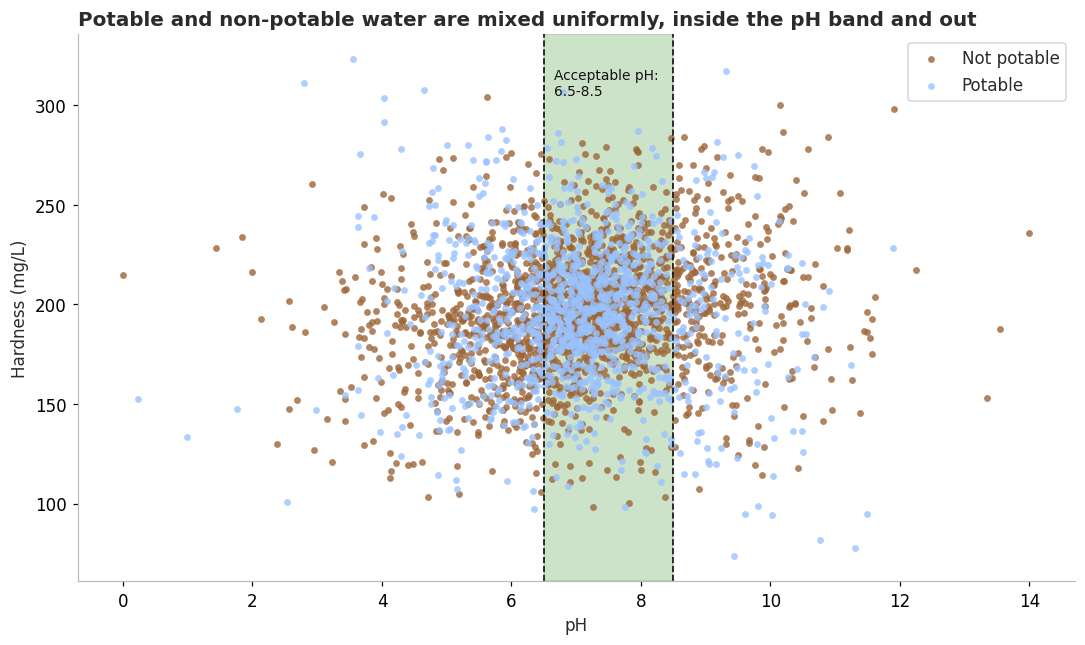

In [116]:
fig, ax = plot_scatter(df_imputed, y_col="Hardness")
ph_band(ax)
ax.text(6.65, ax.get_ylim()[1] * 0.95, "Acceptable pH: \n6.5-8.5",
        fontsize=9, color=C["boundary"], va="top")
ax.set_title("Potable and non-potable water are mixed uniformly, inside the pH band and out")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "05-hardness-vs-ph.png")
plt.show()

**Takeaway.** The classes are interleaved everywhere; no corner of this plane is
predominantly one class, inside the acceptable pH window or outside it. That shows **no
straight boundary on these two axes separates the classes** — not that the features are
uninformative, which is a different claim and one section 7 overturns.

### Solids against pH

The document sets the ideal level of dissolved solids at 500 mg/L and the maximum at 1,000.
The inset shows that region at the scale the document assumes.

Samples at or below the 1,000 mg/L maximum: 2 of 3,114


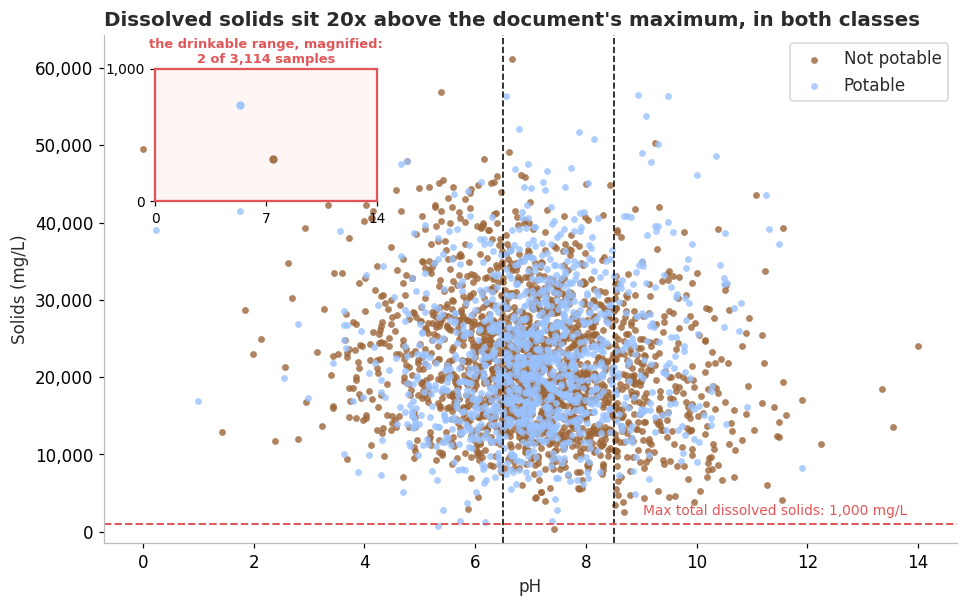

In [117]:
fig, ax = plot_scatter(df_imputed, y_col="Solids")
ph_band(ax, label=False)

_, solids_max, solids_label = GUIDELINES["Solids"]
ax.axhline(solids_max, color=C["not_ok"], linestyle="--", linewidth=1.3)
ax.text(13.8, solids_max + 1200, solids_label, color=C["not_ok"], fontsize=9, ha="right")
ax.yaxis.set_major_formatter(FuncFormatter(thousands))
ax.set_ylim(-1500, ax.get_ylim()[1])

# Inset: the same two axes, cropped to the range the document calls drinkable.
n_drinkable = int((df_imputed["Solids"] <= solids_max).sum())
ax_inset = inset_axes(ax, width="26%", height="26%", loc="upper left",
                      bbox_to_anchor=(0.05, -0.05, 1, 1), bbox_transform=ax.transAxes)
ax_inset.set_facecolor("#FDF6F5")
for cls in (0, 1):
    subset = df_imputed[df_imputed["Potability"] == cls]
    ax_inset.scatter(subset["ph"], subset["Solids"],
                     color=CLASS_COLOR[cls], alpha=0.9, s=30, linewidths=0, zorder=3)
ax_inset.set_ylim(0, solids_max)
ax_inset.set_xlim(0, 14)
ax_inset.set_xticks([0, 7, 14])
ax_inset.set_yticks([0, solids_max])
ax_inset.set_yticklabels(["0", "1,000"])
ax_inset.tick_params(labelsize=9)
ax_inset.set_title(f"the drinkable range, magnified:\n{n_drinkable} of "
                   f"{len(df_imputed):,} samples",
                   fontsize=8.5, loc="center", pad=4, color=C["not_ok"])
ax_inset.grid(False)
for spine in ax_inset.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor(C["not_ok"])
    spine.set_linewidth(1.5)

ax.set_title("Dissolved solids sit 20x above the document's maximum, in both classes")
# No tight_layout here: inset_axes is not compatible with it and warns. The figure is
# already correctly laid out, and savefig's bbox="tight" handles the margins.

print(f"Samples at or below the 1,000 mg/L maximum: "
      f"{(df_imputed['Solids'] <= 1000).sum()} of {len(df_imputed):,}")

plt.savefig(FIGURE_DIR / "06-solids-vs-ph.png")
plt.show()

**Takeaway.** The inset is nearly empty: two samples out of 3,114 fall inside the range
the document describes, and the main panel sits entirely above it. The threshold is not
separating good water from bad, it is sitting at the very bottom of the data. If I could
keep one plot from this notebook, it would be this one.

### Chloramines against pH

Here the acceptable region is a rectangle: pH between 6.5 and 8.5, **and** chloramines
below 4 mg/L.

Inside the box:  n =  36, potable 36.1%
Outside the box: n = 3078, potable 39.3%
Base rate across the whole file: 39.0%


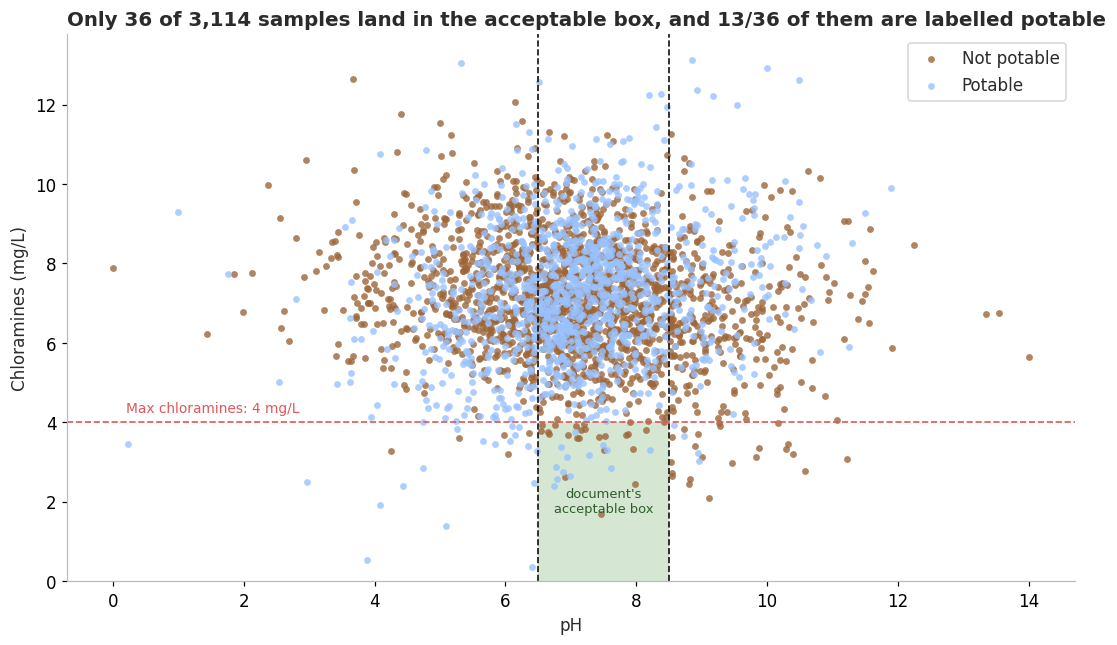

In [118]:
fig, ax = plot_scatter(df_imputed, y_col="Chloramines")
ph_band(ax, label=False)

low, high, _ = GUIDELINES["ph"]
_, chlor_max, chlor_label = GUIDELINES["Chloramines"]
ax.axhline(chlor_max, color=C["not_ok"], linestyle="--", linewidth=1.1)
ax.text(0.2, chlor_max + 0.25, chlor_label, fontsize=9, color=C["not_ok"])
ax.set_ylim(bottom=0)

ax.add_patch(Rectangle((low, 0), high - low, chlor_max,
                       facecolor=C["ok"], edgecolor="none", alpha=0.25, zorder=0))
ax.text((low + high) / 2, chlor_max / 2, "document's\nacceptable box",
        fontsize=8.5, ha="center", va="center", color="#2F5D2A")

inside = (df_imputed["ph"].between(low, high)
          & (df_imputed["Chloramines"] <= chlor_max))
inside_potable = df_imputed.loc[inside, "Potability"].sum()
ax.set_title(f"Only {inside.sum()} of {len(df_imputed):,} samples land in the "
             f"acceptable box, and {inside_potable}/{inside.sum()} of them are labelled potable")
plt.tight_layout()

print(f"Inside the box:  n = {inside.sum():3d}, potable {inside_potable/inside.sum():.1%}")
print(f"Outside the box: n = {(~inside).sum():3d}, potable "
      f"{df_imputed.loc[~inside, 'Potability'].mean():.1%}")
print(f"Base rate across the whole file: {BASE_RATE:.1%}")


plt.savefig(FIGURE_DIR / "07-chloramines-vs-ph.png")
plt.show()

**Takeaway.** It looks surprising that potable samples appear above the chloramine limit
at all. Measured, it is not: 36.1% of the samples inside the acceptable box are labelled
potable against 39.3% of those outside it — if anything slightly *worse* inside the box,
and on 36 samples a 3-point gap is well inside what chance produces. The box carries no
information about the label.

Note also how few samples land in the box — as with `Solids`, the threshold sits at the
edge of the data rather than through the middle of it. That is the recurring pattern of
this section, and the table two cells down puts a number on it for all eight bands.

### Every band at once, as one interactive chart

Rather than repeat the same figure seven more times: one chart with a **dropdown for the
vertical axis**. The pH window and the selected feature's own threshold are drawn for each
choice, and the subtitle reports the potable rate inside and outside the band.


In [119]:
scatter_features = [f for f in FEATURES if f != "ph"]
ph_low, ph_high, _ = GUIDELINES["ph"]

fig = go.Figure()

for feature in scatter_features:
    for cls in (0, 1):
        subset = df_imputed[df_imputed["Potability"] == cls]
        unit = f" {UNITS[feature]}" if UNITS.get(feature) else ""
        fig.add_trace(go.Scattergl(
            x=subset["ph"], y=subset[feature],
            mode="markers",
            name=CLASS_LABEL[cls],
            marker=dict(color=CLASS_COLOR[cls], size=5, opacity=0.9),
            visible=(feature == scatter_features[0]), # Show the first feature initially; hide all the other features initially.
            hovertemplate=("pH %{x:.2f}<br>" + feature + " %{y:,.1f}" + unit
                           + "<br>" + CLASS_LABEL[cls] + "<extra></extra>"), #<br> is a line break in HTML. <extra></extra> removes the trace name from the tooltip.
        ))


def band_shapes(feature):
    """Layout shapes: the pH window plus this feature's own threshold line."""
    shapes = [dict(type="rect", xref="x", yref="paper",
                   x0=ph_low, x1=ph_high, y0=0, y1=1,
                   fillcolor=C["ok"], opacity=0.5, line_width=0, layer="below")]
    bound = GUIDELINES.get(feature)
    if bound is not None and bound[1] is not None:
        shapes.append(dict(type="line", xref="paper", yref="y",
                           x0=0, x1=1, y0=bound[1], y1=bound[1], # the line is horizontal, so y0=y1=bound[1] both are the max bound
                           line=dict(color=C["not_ok"], width=1.6, dash="dash")))
    return shapes


def band_summary(feature):
    """Potable rate inside vs outside this feature's acceptable band."""
    bound = GUIDELINES.get(feature)
    if bound is None or bound[1] is None:
        return "no threshold specified in the document"
    inside = df_imputed[feature] <= bound[1]
    if inside.sum() == 0 or (~inside).sum() == 0:
        return f"every sample falls on one side of the {bound[1]:,g} threshold"
    return (f"potable {df_imputed.loc[inside, 'Potability'].mean():.0%} "
            f"inside the band (n={inside.sum():,})  vs  "
            f"{df_imputed.loc[~inside, 'Potability'].mean():.0%} outside "
            f"(n={(~inside).sum():,})")


buttons = []
for i, feature in enumerate(scatter_features):
    visible = [False] * (2 * len(scatter_features)) # because there are two traces per feature (one for each class), we need to set visibility for both traces of the feature.
    visible[2 * i] = visible[2 * i + 1] = True
    unit = f" ({UNITS[feature]})" if UNITS.get(feature) else ""
    buttons.append(dict(
        label=feature,
        method="update",
        args=[{"visible": visible},
              {"yaxis.title.text": feature + unit,
               "shapes": band_shapes(feature),
               "title.text": (f"{feature} against pH<br>"
                              f"<sup>{band_summary(feature)}</sup>")}],
    ))

first = scatter_features[0]
fig.update_layout(
    **PLOTLY_LAYOUT,
    height=560,
    xaxis_title="pH",
    yaxis_title=first + (f" ({UNITS[first]})" if UNITS.get(first) else ""),
    title=dict(text=f"{first} against pH<br><sup>{band_summary(first)}</sup>",x=0.4, xanchor="left"),
    shapes=band_shapes(first),
    legend=dict(orientation="h", yanchor="bottom", y=1.0, xanchor="right", x=1,bordercolor=C["grid"], borderwidth=1, bgcolor="white"),
    updatemenus=[dict(buttons=buttons, direction="down", showactive=True,
                      x=0.0, xanchor="left", y=1.16, yanchor="top",
                      bgcolor="white", bordercolor=C["grid"])],
)
fig.show()

### Does *any* band predict the label?

The dropdown gives the answer one feature at a time. This table gives it all at once.

In [120]:
rows = []
for feature, (low, high, _) in GUIDELINES.items():
    series = df[[feature, TARGET]].dropna()
    lower = -np.inf if low is None else low
    upper = np.inf if high is None else high
    inside = series[feature].between(lower, upper)

    if inside.sum() == 0 or (~inside).sum() == 0: # if all data points are on one side of the threshold, we cannot compute a chi-squared test.
        rows.append({"feature": feature, 
                     "band": f"{low or 0:g} - {high:g}",
                     "n inside": int(inside.sum()),
                     "potable % inside": np.nan, "potable % outside": np.nan,
                     "p": np.nan})
        continue

    _, p_value, _, _ = chi2_contingency(pd.crosstab(inside, series[TARGET]))
    rows.append({
        "feature": feature,
        "band": f"{low or 0:g} - {high:g}",
        "n inside": int(inside.sum()),
        "potable % inside": round(series.loc[inside, TARGET].mean() * 100, 1),
        "potable % outside": round(series.loc[~inside, TARGET].mean() * 100, 1),
        "p": round(p_value, 3),
    })

band_table = pd.DataFrame(rows)
band_table["difference (pp)"] = (band_table["potable % inside"]
                                 - band_table["potable % outside"]).round(1)
print(f"Base rate: {BASE_RATE:.1%} potable\n")
display(band_table.style.hide(axis="index"))

all_bands = np.ones(len(df), dtype=bool)
for feature, (low, high, _) in GUIDELINES.items():
    lower = -np.inf if low is None else low
    upper = np.inf if high is None else high
    all_bands &= df[feature].between(lower, upper).fillna(False).values
print(f"Samples satisfying EVERY threshold in the document: {all_bands.sum()}")

Base rate: 39.0% potable



feature,band,n inside,potable % inside,potable % outside,p,difference (pp)
ph,6.5 - 8.5,1328,43.900000,35.600000,0.000000,8.300000
Solids,0 - 1000,2,50.000000,39.000000,1.000000,11.000000
Chloramines,0 - 4,89,40.400000,39.000000,0.864000,1.400000
Sulfate,0 - 1000,2495,nan,nan,nan,nan
Conductivity,0 - 400,1314,39.300000,38.800000,0.832000,0.500000
Organic_carbon,0 - 2,0,nan,nan,nan,nan
Trihalomethanes,0 - 80,2512,39.200000,39.500000,0.921000,-0.300000
Turbidity,0 - 5,2962,39.200000,37.300000,0.543000,1.900000


Samples satisfying EVERY threshold in the document: 0


**Takeaway — one band out of eight does anything, and no sample passes all of them.**

**How to read the table.** For each feature the samples are split into those **inside** the
document's band and those **outside** it, and the share labelled potable is compared
between the two groups.

- `potable % inside` and `potable % outside` are the two shares being compared. If a band
  captured something real, the first would be clearly higher than the second.
- `difference (pp)` is the gap in **percentage points**. 43.9 against 35.6 is a gap of
  8.3 pp — samples inside the pH window are potable 8.3 percentage points more often.
  (Percentage points, not per cent: 8.3 pp on a base of 35.6 is 23% more often in relative
  terms.)
- `p` is the chi-squared p-value from the same test as section 4 — the probability of a gap
  at least this large if being inside the band and being potable were independent. Small p:
  hard to explain as chance. Large p: exactly the size chance routinely produces.
- `n inside` is how many samples are in the band at all. A huge gap resting on a handful of
  rows means nothing, and the p-value is what catches that.

**`ph` is the only threshold that separates the classes.** 43.9% potable inside the 6.5-8.5
window against 35.6% outside — 8.3 pp, p < 0.001, so under one chance in a thousand of
arising from nothing. Chloramines, conductivity, trihalomethanes and turbidity land within
two points of the base rate with p between 0.54 and 0.92, meaning gaps that chance produces
between roughly half and nine times out of ten. That is no evidence of any effect.

**Three rows say nothing rather than "no effect".** No sample is inside the
`Organic_carbon` band and none is outside the `Sulfate` one, so there is no comparison to
make — the cells are blank rather than zero. The `Solids` row's eleven-point gap rests
entirely on the **two** samples that clear the threshold, and its p-value of 1.00 says so:
with n = 2 on one side, no observed gap could be distinguished from chance. That row is not
a finding.

And **not one of the 3,276 samples satisfies every threshold simultaneously.** Whatever
rule generated `Potability`, it was not the document's checklist.

---
## 6. The correlation question

The natural next move, once the guideline bands have failed, is to stop using the
document's cut points and ask whether the raw measurements track the label at all. That is
what a correlation coefficient is for, and it is worth being precise about what it does and
does not answer before reading one.

Two relationships get tested here: trihalomethanes against organic carbon, where the
document's chemistry predicts a positive slope, and every feature against the label.

### The coefficient itself

Pearson's correlation between two variables $X$ and $Y$ measured over $n$ samples:

$$
r_{XY} \;=\; \frac{\displaystyle\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}
                   {\sqrt{\displaystyle\sum_{i=1}^{n} (x_i - \bar{x})^{2}}\;
                    \sqrt{\displaystyle\sum_{i=1}^{n} (y_i - \bar{y})^{2}}}
$$



Three consequences matter for this notebook, and all three fall straight out of the
formula:

- It is a **sum over samples**, so positive and negative terms cancel. A relationship that
  is positive over half of a feature's range and negative over the other half sums to
  approximately nothing. Section 6 ends on exactly this case.
- Each term is a **product of two deviations** and nothing else — no cut points, no curves.
  Only a straight-line tendency registers at all.
- It takes **two variables at a time**. There is nowhere in the formula to express "$X$
  matters only when $Y$ is high". Section 7 exploits precisely that gap: correlating the
  *product* $z_X z_Y$ of two standardised columns with the label rewrites an interaction
  into a form $r$ can see.

When one of the two variables is a 0/1 label, as `Potability` is, this reduces to the
point-biserial correlation — the same arithmetic, and it amounts to comparing the feature's
mean between the two classes.

### Trihalomethanes against organic carbon

The document states that trihalomethanes form when chlorine reacts with organic matter, so
their concentration should depend on how much organic carbon is present. In this file that
would show up as a positive slope.

r(Organic_carbon, Trihalomethanes) = -0.0133


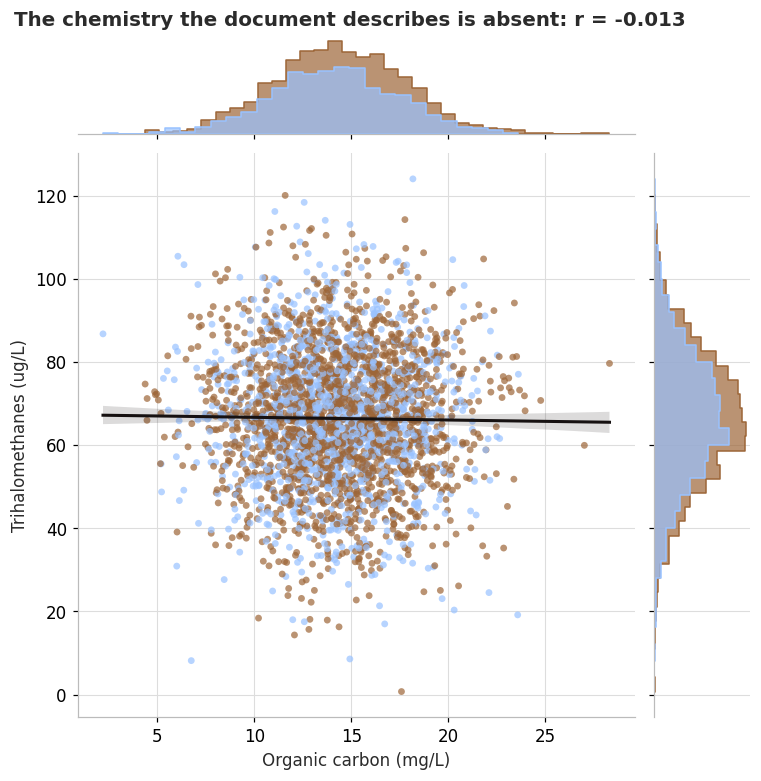

In [121]:
g = sns.JointGrid(data=df_imputed, x="Organic_carbon", y="Trihalomethanes", height=7)

sns.scatterplot(
    data=df_imputed, x="Organic_carbon", y="Trihalomethanes", hue="Potability",
    palette=CLASS_COLOR, alpha=0.7, s=20, linewidth=0, ax=g.ax_joint, legend=False,
)
sns.regplot(
    data=df_imputed, x="Organic_carbon", y="Trihalomethanes",
    scatter=False, color=C["boundary"], ax=g.ax_joint,
    line_kws=dict(linewidth=2),
)
for cls in (0, 1):
    subset = df_imputed[df_imputed["Potability"] == cls]
    sns.histplot(x=subset["Organic_carbon"], element="step", fill=True, alpha=0.7,
                 color=CLASS_COLOR[cls], ax=g.ax_marg_x, legend=False)
    sns.histplot(y=subset["Trihalomethanes"], element="step", fill=True, alpha=0.7,
                 color=CLASS_COLOR[cls], ax=g.ax_marg_y, legend=False)

r_toc = df_imputed["Organic_carbon"].corr(df_imputed["Trihalomethanes"])
print(f"r(Organic_carbon, Trihalomethanes) = {r_toc:+.4f}")
g.ax_joint.set_xlabel("Organic carbon (mg/L)")
g.ax_joint.set_ylabel("Trihalomethanes (ug/L)")
g.ax_joint.grid(True)
g.figure.suptitle(
    f"The chemistry the document describes is absent: r = {r_toc:+.3f}",
    y=1.01, x=0.02, ha="left", fontsize=13, fontweight="semibold")
plt.savefig(FIGURE_DIR / "08-thm-vs-organic-carbon.png")
plt.show()

**Takeaway.** The regression line is flat — the correlation printed above the chart is
within 0.02 of zero. There is no dependence of trihalomethanes on organic carbon here, and
the marginal histograms show the two classes sitting on top of each other in both
directions as well.

The reason generalises to the whole file: **the columns were drawn independently of one
another.** In real water chemistry, hardness, conductivity and dissolved solids are close
to three measurements of the same underlying quantity and would correlate at 0.7 or above.
The next cell shows what they do instead.

In [122]:
feature_corr = df_imputed[FEATURES].corr()

# .where(condition) keeps values where the condition is True and replaces values where it is False with NaN.
# here it removes the corr of each feature with itself (the diagonal of the correlation matrix) by replacing it with NaN.
off_diagonal = feature_corr.where(~np.eye(len(FEATURES), dtype=bool))

pairs = (off_diagonal.stack()
         .rename("r")
         .reset_index()
         .rename(columns={"level_0": "feature A", "level_1": "feature B"}))
pairs = pairs[pairs["feature A"] < pairs["feature B"]]
pairs["|r|"] = pairs["r"].abs()
pairs = pairs.sort_values("|r|", ascending=False)

print("Strongest feature-to-feature correlations in the file:")
print(pairs.head(5).drop(columns="|r|").round(3).to_string(index=False))
print(f"\nmedian |r| across all {len(pairs)} pairs: {pairs['|r|'].median():.3f}")
print("\nFor comparison, in real water chemistry Hardness / Conductivity / Solids "
      "would correlate at 0.7+.")
print(f"  here, Hardness vs Conductivity: "
      f"{df_imputed['Hardness'].corr(df_imputed['Conductivity']):+.3f}")
print(f"        Solids   vs Conductivity: "
      f"{df_imputed['Solids'].corr(df_imputed['Conductivity']):+.3f}")

Strongest feature-to-feature correlations in the file:
  feature A feature B      r
     Solids   Sulfate -0.170
   Hardness   Sulfate -0.118
     Solids        ph -0.097
   Hardness        ph  0.090
Chloramines    Solids -0.066

median |r| across all 36 pairs: 0.018

For comparison, in real water chemistry Hardness / Conductivity / Solids would correlate at 0.7+.
  here, Hardness vs Conductivity: -0.020
        Solids   vs Conductivity: +0.016


### Correlation with the label

The same question, asked of `Potability` itself: does any of the nine measurements track
the label?

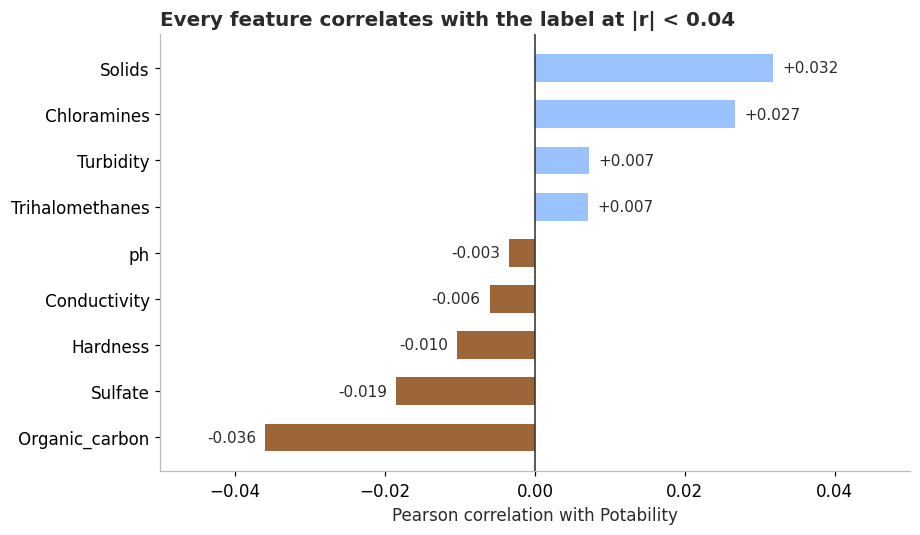

In [123]:
target_corr = (df_imputed.corr(numeric_only=True)[TARGET]
               .drop(TARGET)
               .sort_values())

fig, ax = plt.subplots(figsize=(8.5, 5))
bar_colors = [C["potable"] if v >= 0 else C["not_potable"] for v in target_corr]
ax.barh(range(len(target_corr)), target_corr.values, color=bar_colors, height=0.6)

for i, value in enumerate(target_corr.values):
    ax.text(value + (0.0012 if value >= 0 else -0.0012), i, f"{value:+.3f}",
            va="center", ha="left" if value >= 0 else "right", fontsize=10)

ax.set_yticks(range(len(target_corr)), target_corr.index)
ax.axvline(0, color=C["text"], linewidth=1)
ax.set_xlim(-0.05, 0.05)
ax.set_xlabel("Pearson correlation with Potability")
ax.set_title("Every feature correlates with the label at |r| < 0.04")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "09-correlation-with-target.png")
plt.show()

**Takeaway — and the correction the rest of this notebook rests on.**

Every feature correlates with the label at |r| < 0.04. The chart is accurate. The tempting
reading of it — *there is nothing here to find* — is not.

A Pearson correlation between a feature and a binary label detects one specific thing, and
the formula above says which: a **linear, monotone, marginal** relationship. It is blind to
three others, and this dataset contains the third.

- **Non-monotone effects.** If potable water sits in the *middle* of a feature's range,
  samples at the low end and samples at the high end contribute terms of opposite sign that
  cancel in the sum, driving $r$ toward zero.
- **Threshold effects.** A jump in the potable rate at one cut point barely moves a
  coefficient fitted across the whole range.
- **Interactions.** If the label depends on two features *jointly*, each one can be
  completely uninformative on its own. Nothing in a two-variable formula can see this.

The pH band from section 5 is an instance of the first, which is why its correlation is
+0.014 — the next two cells make that visible. Section 7 is about the third.

In [124]:
ph_deciles = pd.qcut(complete_cases["ph"], 10)
by_decile = complete_cases.groupby(ph_deciles, observed=True)[TARGET].agg(["size", "mean"])

# by_decile
for interval in by_decile.index:
    print(interval.mid)

2.684
5.4915
6.080500000000001
6.5125
6.866
7.2135
7.615500000000001
8.070500000000001
8.688500000000001
11.5335


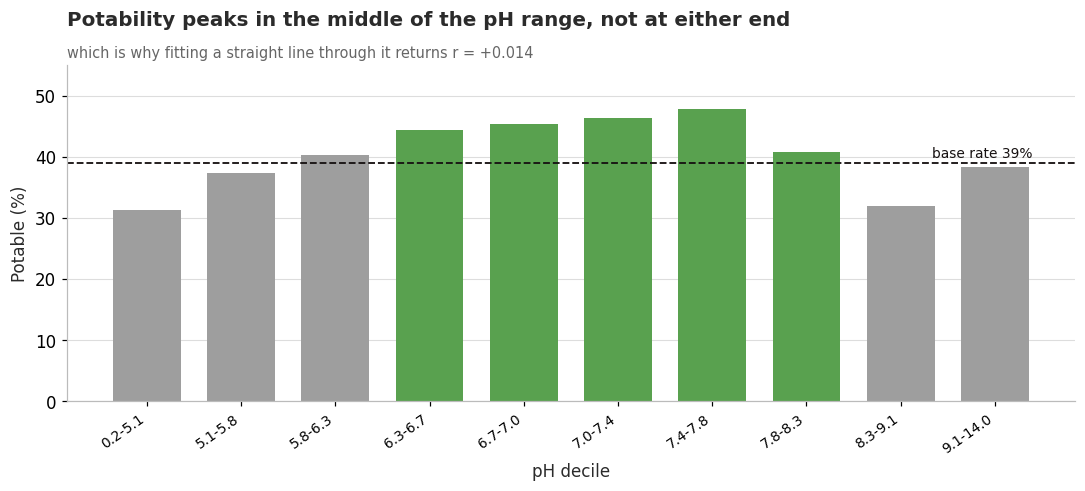

                size  potable %
ph                             
(0.226, 5.142]   202       31.2
(5.142, 5.841]   201       37.3
(5.841, 6.32]    201       40.3
(6.32, 6.705]    201       44.3
(6.705, 7.027]   201       45.3
(7.027, 7.4]     201       46.3
(7.4, 7.831]     201       47.8
(7.831, 8.31]    201       40.8
(8.31, 9.067]    201       31.8
(9.067, 14.0]    201       38.3


In [125]:
# pH is the worked example of a non-monotone effect: a real band effect, invisible to r.
ph_deciles = pd.qcut(complete_cases["ph"], 10)
by_decile = complete_cases.groupby(ph_deciles, observed=True)[TARGET].agg(["size", "mean"])

ph_low, ph_high, _ = GUIDELINES["ph"]


fig, ax = plt.subplots(figsize=(10, 4.6))
centres = [interval.mid for interval in by_decile.index]
inside_band = [ph_low <= c <= ph_high for c in centres]
bar_colors = [C["ok"] if ok else C["neutral"] for ok in inside_band]

ax.bar(range(len(by_decile)), by_decile["mean"] * 100, color=bar_colors, width=0.72)
ax.axhline(BASE_RATE * 100, color=C["boundary"], linestyle="--", linewidth=1.2)
ax.text(9.4, BASE_RATE * 100 + 0.8, f"base rate {BASE_RATE:.0%}",
        ha="right", fontsize=9, color=C["boundary"])

ax.set_xticks(range(len(by_decile)),
              [f"{i.left:.1f}-{i.right:.1f}" for i in by_decile.index],
              rotation=35, ha="right", fontsize=9)
ax.set_xlabel("pH decile")
ax.set_ylabel("Potable (%)")
ax.set_ylim(0, 55)
titled(ax, "Potability peaks in the middle of the pH range, not at either end",
       "which is why fitting a straight line through it returns r = +0.014")
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "10-ph-deciles.png")
plt.show()

print(by_decile.assign(**{"potable %": (by_decile["mean"] * 100).round(1)})
               .drop(columns="mean").to_string())

**Takeaway.** The potable rate climbs from 31% in the most acidic decile to 48% around
pH 7.4–7.8, then falls back to 32% by pH 8.3–9.1 — a genuine, sizeable **hump**. A straight
line fitted through it has almost no slope, which is exactly the +0.014 the bar chart
reported. The correlation was never wrong; it was answering a question about straight lines.

---
## 7. What the label is actually made of

If the label depends on no feature alone, the next candidate is a **pair**. For each of the
36 pairs among nine features I standardise both columns and correlate their product with
the label — a high value means the label depends on the two *jointly*, in a way neither
shows on its own.

In [126]:
standardised = complete_cases[FEATURES].apply(lambda s: (s - s.mean()) / s.std())

interactions = []
for i, a in enumerate(FEATURES):
    for b in FEATURES[i + 1:]:
        interactions.append({
            "pair": f"{a} x {b}",
            "feature A": a,
            "feature B": b,
            "r with Potability": (standardised[a] * standardised[b]).corr(complete_cases[TARGET]),
        })

interactions = pd.DataFrame(interactions)
interactions["|r|"] = interactions["r with Potability"].abs()
interactions = interactions.sort_values("|r|", ascending=False).reset_index(drop=True)

print("Strongest pairwise interactions (complete cases, n = "
      f"{len(complete_cases):,}):\n")
print(interactions.head(6)[["pair", "r with Potability"]].round(4).to_string(index=False))
print(f"\nmedian |r| across all {len(interactions)} pairs: "
      f"{interactions['|r|'].median():.4f}")
print(f"strongest single-feature |r| for comparison:        "
      f"{target_corr.abs().max():.4f}")

Strongest pairwise interactions (complete cases, n = 2,011):

                     pair  r with Potability
             ph x Sulfate            -0.2225
         ph x Chloramines             0.1721
         Solids x Sulfate            -0.1698
              ph x Solids             0.1266
     Solids x Chloramines            -0.0798
Sulfate x Trihalomethanes            -0.0669

median |r| across all 36 pairs: 0.0215
strongest single-feature |r| for comparison:        0.0360


**Takeaway.** `ph x Sulfate` correlates **-0.22** with the label: **six times** the
strongest single-feature correlation anywhere in the dataset (0.036), **ten times** the
median interaction (0.022), and **fifteen times** its own two ingredients (+0.015 and
-0.015).

That last comparison is the whole point. Neither pH nor sulfate says anything about the
label on its own; their product says a great deal.

Two reasons to believe it rather than treat it as the winner of a 36-way lottery. First,
the size: an effect of -0.22 at n = 2,011 is far outside the range that testing 36 pairs
can produce by chance — the median pair here comes in at 0.022, and the whole distribution
of the other 35 sits an order of magnitude below the top one. Second, and more convincing
than any p-value, the effect has a **shape**, and the two rate grids below show that shape
is coherent rather than a scattering of lucky cells.

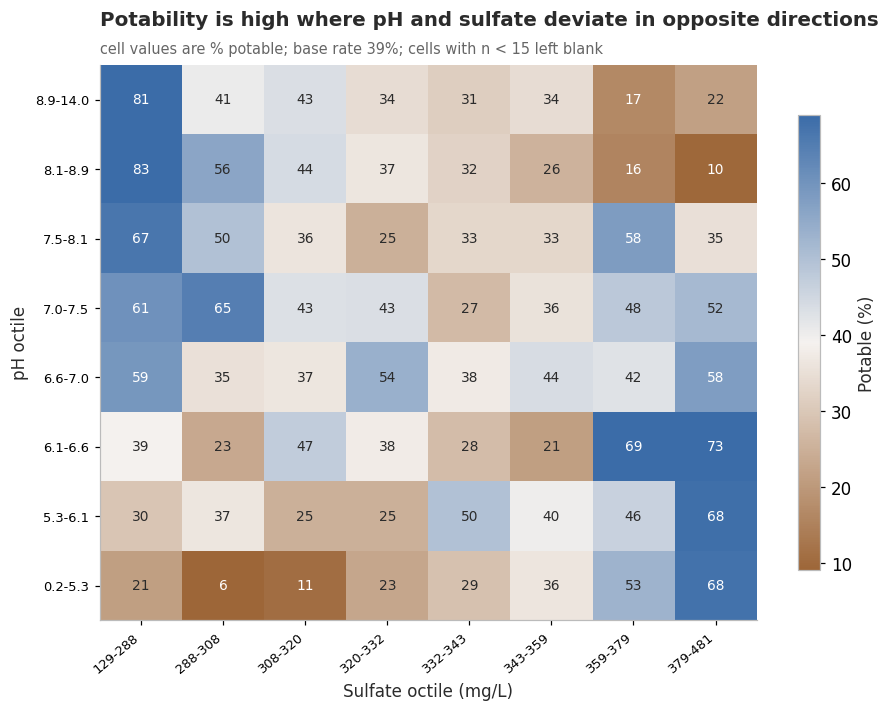

Corner blocks (2x2 octiles each).  Base rate 39.0%

  high pH + low sulfate    n = 113   potable  64.6%
  low pH + high sulfate    n = 141   potable  60.3%
  high pH + high sulfate   n = 120   potable  16.7%
  low pH + low sulfate     n = 125   potable  22.4%


In [127]:
def rate_grid(frame, feature_a, feature_b, bins=8, min_count=15):
    """Potable rate on a quantile grid of two features. Sparse cells -> NaN."""
    a_bin = pd.qcut(frame[feature_a], bins, labels=False, duplicates="drop")
    b_bin = pd.qcut(frame[feature_b], bins, labels=False, duplicates="drop")
    grouped = frame.groupby([a_bin, b_bin], observed=True)[TARGET].agg(["size", "mean"])
    rate = grouped["mean"].unstack() * 100
    count = grouped["size"].unstack()
    return rate.where(count >= min_count), count


def edge_labels(frame, feature, bins=8):
    edges = pd.qcut(frame[feature], bins, retbins=True, duplicates="drop")[1]
    return [f"{lo:.0f}-{hi:.0f}" if abs(hi) > 20 else f"{lo:.1f}-{hi:.1f}"
            for lo, hi in zip(edges[:-1], edges[1:])]


rate, count = rate_grid(complete_cases, "ph", "Sulfate")

fig, ax = plt.subplots(figsize=(8.6, 6.6))
im = ax.imshow(rate.values, cmap=DIV, vmin=BASE_RATE * 100 - 30, vmax=BASE_RATE * 100 + 30,
               origin="lower", aspect="auto")

for i in range(rate.shape[0]):
    for j in range(rate.shape[1]):
        value = rate.values[i, j]
        if np.isnan(value):
            continue
        ax.text(j, i, f"{value:.0f}", ha="center", va="center", fontsize=9,
                color="white" if abs(value - BASE_RATE * 100) > 18 else C["text"])

ax.set_xticks(range(rate.shape[1]), edge_labels(complete_cases, "Sulfate"),
              rotation=40, ha="right", fontsize=8.5)
ax.set_yticks(range(rate.shape[0]), edge_labels(complete_cases, "ph"), fontsize=8.5)
ax.set_xlabel("Sulfate octile (mg/L)")
ax.set_ylabel("pH octile")
titled(ax, "Potability is high where pH and sulfate deviate in opposite directions",
       f"cell values are % potable; base rate {BASE_RATE:.0%}; "
       "cells with n < 15 left blank")
ax.grid(False)
cbar = fig.colorbar(im, ax=ax, shrink=0.82)
cbar.set_label("Potable (%)")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "11-ph-sulfate-saddle.png")
plt.show()

# Corner blocks: 2x2 groups of octiles, so each figure rests on ~130 rows, not ~30.
ph_bin = pd.qcut(complete_cases["ph"], 8, labels=False)
sulfate_bin = pd.qcut(complete_cases["Sulfate"], 8, labels=False)
corners = {
    "high pH + low sulfate":  (ph_bin >= 6) & (sulfate_bin <= 1),
    "low pH + high sulfate":  (ph_bin <= 1) & (sulfate_bin >= 6),
    "high pH + high sulfate": (ph_bin >= 6) & (sulfate_bin >= 6),
    "low pH + low sulfate":   (ph_bin <= 1) & (sulfate_bin <= 1),
}
print(f"Corner blocks (2x2 octiles each).  Base rate {BASE_RATE:.1%}\n")
for label, mask in corners.items():
    print(f"  {label:24s} n = {mask.sum():3d}   potable "
          f"{complete_cases.loc[mask.values, TARGET].mean():6.1%}")

**Takeaway — this is the shape of the label.**

Each corner pools a 2x2 block of octiles, so every figure rests on roughly 130 samples
rather than 30:

| Corner | Potable |
|---|---|
| high pH + low sulfate | **64.6%** |
| low pH + high sulfate | **60.3%** |
| low pH + low sulfate | **22.4%** |
| high pH + high sulfate | **16.7%** |

The base rate is 39%. The two *opposite* corners run at roughly 62%, the two *matching*
corners at roughly 20% — a spread of more than 40 percentage points, out of two columns
that individually correlate with the label at 0.015.

That is a **saddle**: potable when pH and sulfate deviate from their means in *opposite*
directions, not potable when they deviate the *same* way. Average that surface along either
axis and the highs and lows cancel, which is precisely why both marginal correlations sit
within 0.015 of zero and why the bar chart in section 6 looked empty. It is the "sum over
samples" property of the correlation formula, made visible.

Chemically this is backwards — low pH with high sulfate is the signature of acid drainage,
the *least* drinkable combination there is. Together with section 3, that confirms the
pattern describes the generator rather than water. It is still the correct description of
the label.

In [128]:
# The same view for the other strong pairs, plus a control pair with no interaction.
pair_choices = [(row["feature A"], row["feature B"])
                for _, row in interactions.head(3).iterrows()]
pair_choices.append(tuple(interactions.iloc[-1][["feature A", "feature B"]]))

fig = go.Figure()
for index, (a, b) in enumerate(pair_choices):
    rate, count = rate_grid(complete_cases, a, b)
    fig.add_trace(go.Heatmap(
        z=rate.values,
        x=edge_labels(complete_cases, b),
        y=edge_labels(complete_cases, a),
        customdata=count.values,
        colorscale=[[0, C["not_potable"]], [0.5, "#F5F2EF"], [1, "#3B6CA8"]],
        zmid=BASE_RATE * 100, zmin=5, zmax=75,
        colorbar=dict(title="potable %", thickness=14),
        visible=(index == 0),
        hovertemplate=(a + " %{y}<br>" + b + " %{x}"
                       "<br>potable %{z:.0f}%<br>n = %{customdata}<extra></extra>"),
    ))

buttons = []
for index, (a, b) in enumerate(pair_choices):
    r_value = interactions.loc[
        (interactions["feature A"] == a) & (interactions["feature B"] == b),
        "r with Potability"].iloc[0]
    visible = [i == index for i in range(len(pair_choices))]
    tag = "control pair" if index == len(pair_choices) - 1 else f"rank {index + 1}"
    buttons.append(dict(
        label=f"{a} x {b}",
        method="update",
        args=[{"visible": visible},
              {"xaxis.title.text": f"{b} octile",
               "yaxis.title.text": f"{a} octile",
               "title.text": (f"Potable rate over {a} x {b}<br>"
                              f"<sup>{tag} of 36 &nbsp;|&nbsp; interaction r = "
                              f"{r_value:+.3f} &nbsp;|&nbsp; base rate "
                              f"{BASE_RATE:.0%} &nbsp;|&nbsp; cells with n &lt; 15 "
                              f"left blank</sup>")}],
    ))

a0, b0 = pair_choices[0]
r0 = interactions.iloc[0]["r with Potability"]
fig.update_layout(
    **PLOTLY_LAYOUT,
    height=600,
    xaxis_title=f"{b0} octile",
    yaxis_title=f"{a0} octile",
    title=dict(text=(f"Potable rate over {a0} x {b0}<br><sup>rank 1 of 36 &nbsp;|&nbsp; "
                     f"interaction r = {r0:+.3f} &nbsp;|&nbsp; base rate {BASE_RATE:.0%}"
                     f" &nbsp;|&nbsp; cells with n &lt; 15 left blank</sup>")),
    updatemenus=[dict(buttons=buttons, direction="down", showactive=True,
                      x=0.85, xanchor="left", y=1.15, yanchor="top",
                      bgcolor="white", bordercolor=C["grid"])],
)
fig.show()

**Takeaway.** The control pair at the bottom of the ranking shows what "no interaction"
looks like: a flat wash of cells near the 39% base rate, no structure in any direction. The
three real interactions each show a clear diagonal gradient. That contrast is the check
that the saddle is a property of the data and not of the binning.

In [129]:
# The simplest possible statement of the effect: same side, or opposite sides?
z_ph = standardised["ph"]
z_sulfate = standardised["Sulfate"]
interaction_term = z_ph * z_sulfate

side = np.where(interaction_term > 0, "same side of the mean", "opposite sides")
by_side = (complete_cases.assign(side=side)
           .groupby("side")[TARGET].agg(["size", "mean"]))
by_side["potable %"] = (by_side["mean"] * 100).round(1)

print(by_side.drop(columns="mean").to_string())
print(f"\nbase rate: {BASE_RATE:.1%}")
print(f"\nr(ph, Potability)                 = {complete_cases['ph'].corr(complete_cases[TARGET]):+.4f}")
print(f"r(Sulfate, Potability)            = {complete_cases['Sulfate'].corr(complete_cases[TARGET]):+.4f}")
print(f"r(z_ph * z_Sulfate, Potability)   = {interaction_term.corr(complete_cases[TARGET]):+.4f}")

                       size  potable %
side                                  
opposite sides          984       49.2
same side of the mean  1027       31.8

base rate: 39.0%

r(ph, Potability)                 = +0.0145
r(Sulfate, Potability)            = -0.0153
r(z_ph * z_Sulfate, Potability)   = -0.2225


**Takeaway.** Without the grid at all: when pH and sulfate sit on **opposite** sides of
their means, 49.2% of samples are potable; on the **same** side, 31.8%. One yes/no question
separates the classes by 17 percentage points, built from two columns that individually
separate them by less than one.

---
## 8. Conclusion

**What I found**

1. **The file was generated, not measured.** Every non-null value in every column is
   distinct and carries 12-15 decimal places, where an instrument would round and repeat.
   99.9% of samples exceed the document's limit for dissolved solids and 8% exceed the
   concentration of seawater. The nine columns are mutually near-independent
   (median |r| = 0.02) where real chemistry would put hardness, conductivity and solids
   above 0.7, and the trihalomethane/organic-carbon reaction the document describes is
   absent (r = -0.013).

2. **The missing values are missing completely at random with respect to the label**
   (differences of 1.1-1.9 pp, all p > 0.15). That is what makes dropping and imputing
   rows defensible here, and the class balance before and after cleaning confirms it:
   39.01% potable becomes 39.27% after 162 rows are dropped.

3. **Seven of the document's eight guideline bands do nothing.** Only the pH window
   separates the classes — 43.9% potable inside against 35.6% outside, p < 0.001. Three
   bands have no samples on one side at all, so they cannot be tested. And no sample in the
   file satisfies all eight thresholds simultaneously, which rules out the document's
   checklist as the rule that generated the label.

4. **"No correlation" was a true statement about straight lines, not about information.**
   Every feature correlates with `Potability` at |r| < 0.04. pH nonetheless has a clear
   hump-shaped effect — 31% potable in the most acidic decile, 48% around pH 7.4-7.8, 32%
   by pH 8.3-9.1 — that a straight line averages away to +0.014.

5. **The label is driven by an interaction between pH and sulfate.** Water is labelled
   potable when the two sit on *opposite* sides of their means (49.2%) and not when they
   sit on the same side (31.8%) — a 17-point separation from one yes/no question, built out
   of two columns that individually separate the classes by less than one point. The
   product of the two standardised columns correlates -0.22 with the label, six times the
   strongest single-feature correlation in the file.

**What surprised me.** The correlation bar chart, which looks like a dead end, turned out
to be the most informative plot in the notebook — once I stopped reading "r ~ 0" as "no
relationship" and started reading it as "no *linear marginal* relationship". The entire
result was hiding in that gap.

Second, my own imputer. Writing k-nearest neighbours by hand was worth doing, but what it
taught me only appeared once I measured it: `Solids` supplied 98% of an unscaled Manhattan
distance, so a nine-feature k-NN was a one-feature k-NN wearing a disguise. An unscaled
distance is a one-column distance, and nothing in the output announces it.

**Limitations**

- The data is synthetic, so every finding here describes the generator, not drinking water.
  The pH-sulfate saddle is chemically backwards, which is itself part of the evidence for
  that.
- The interaction search tested 36 pairs and I report the largest. The size of the top
  effect and the coherence of its shape are what argue against it being a fluke, but the
  rank ordering below the top three should not be over-read.
- Every reported statistic uses complete cases, 2,011 of 3,276 rows. The plots use the
  imputed frame, 3,114 rows.
- I never identified the generating rule itself, only its shape.
- The thresholds tested are the project document's, not the WHO's, and several of them are
  far stricter than any published standard.



---
## Acknowledgement

I used an AI assistant while producing this notebook: as a reviewer of my
reasoning, as a source of methods I had not used before — and to tighten the code and the
writing.

Every result reported here I ran and checked myself, and every conclusion is one I can
defend. 